In [5]:
import sys
print(sys.executable)

c:\Users\sayeem\AppData\Local\Programs\Python\Python310\python.exe


# Corrected 80/20 CTGAN Model Experiments (n = 1,481 real observations)

This notebook documents the corrected 80/20 experiment. The 1,481 original real observations are split stratified into 1,184 real training observations and 297 untouched real test observations before any normalization, CTGAN fitting, synthetic-data generation, or balancing.

Normalization parameters are calculated from real training predictors only. The same training-derived parameters are applied to the test predictors; no test-derived statistics are used. Target class labels remain unnormalized.

CTGAN is trained only on the minority class within the real training data. Synthetic minority observations are added only to the training data. The six models are trained on the augmented training data and evaluated only on the untouched real test data.

**Update (Reviewer Revision):** This corrected 80/20 workflow addresses the CTGAN leakage concern for the primary single-split evaluation.

> **Important:** The existing 5-fold CV section is inherited from the previous analysis and is not leakage-corrected. It is not the corrected primary evaluation; a separate leakage-safe 5-fold CV analysis will be performed later.

## Models:

1. Random Forest Classifier
2. Gradient Boosting Classifier
3. XGBoost Classifier
4. CatBoost Classifier
5. Logistic Regression
6. Artificial Neural Network (PyTorch)


## 1. Import Libraries


In [6]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Train-Test Split and Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, roc_auc_score
)

# NEW: Cross-Validation tools
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("All libraries imported successfully!")

Using device: cpu
All libraries imported successfully!


## 2. Load Original Real Data


In [7]:
# Load the original encoded real data
real_df = pd.read_csv(r'../data/Final_Encoded.csv')

print(f"Dataset Shape: {real_df.shape}")
print(f"\nColumns: {list(real_df.columns)}")
real_df.head()

Dataset Shape: (1481, 31)

Columns: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Current_CGPA5', 'CGPA3_Class', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


,Age,Gender,Where_live,AVG_Sleep_Per_Night,Regular_Bed_time,Exam_Night_Bed_Time,Holiday_Bed_Time,Regular_WakeUp_Time,Holiday_WakeUp_Time,Have_Regular_Bed_Time,...,Class_Attendance,Sleepiness_During_Class,Skip_Class_for_Sleep,Focus_on_Academic_Task,Impact_of_Sleep_on_Academic,Current_CGPA5,CGPA3_Class,Aware_of_Recomamended_Sleep,Use_Sleep_Tracking_Devices,Sacrifices_Sleep_for_Academics
0,2,1,0,3,4,4,4,2,2,0,...,1,2,0,0,3,2,1,1,0,1
1,2,0,1,1,3,1,1,1,2,0,...,1,0,1,2,3,3,1,1,0,1
2,2,0,1,0,4,4,4,1,2,0,...,0,0,1,0,0,3,1,1,0,1
3,3,0,1,2,2,3,4,1,2,0,...,0,0,0,4,1,3,1,1,0,1
4,2,0,0,1,3,3,3,1,1,0,...,3,1,0,2,1,3,1,0,0,1


In [8]:
# Split the 1,481 original real observations before any normalization, CTGAN operation, synthetic generation, or balancing
# This creates 1,184 real training observations and 297 untouched real test observations.
TARGET_COLUMN = 'CGPA3_Class'
MINORITY_CLASS = 2

real_train_df, real_test_df = train_test_split(
    real_df,
    test_size=0.2,
    random_state=42,
    stratify=real_df[TARGET_COLUMN]
)

print(f"Real training set: {real_train_df.shape[0]} samples")
print(f"Real test set: {real_test_df.shape[0]} samples")

Real training set: 1184 samples
Real test set: 297 samples


In [9]:
# Learn normalization parameters from the 1,184 real training predictors only.
# Apply the same training-derived parameters to test predictors; do not use test statistics.
# Target class labels remain unnormalized.
PREDICTOR_COLUMNS = [col for col in real_train_df.columns if col != TARGET_COLUMN]
train_max_values = real_train_df[PREDICTOR_COLUMNS].max()

normalized_train_df = real_train_df.copy()
normalized_test_df = real_test_df.copy()

for col in PREDICTOR_COLUMNS:
    if train_max_values[col] > 0:
        normalized_train_df[col] = normalized_train_df[col] / train_max_values[col]
        normalized_test_df[col] = normalized_test_df[col] / train_max_values[col]

print("Predictor normalization completed using real training data only.")
print(f"Training predictors: {len(PREDICTOR_COLUMNS)}")

Predictor normalization completed using real training data only.
Training predictors: 30


In [10]:
# Fit CTGAN only on the minority class within the normalized real training data.
# The 297 real test observations and the complete 1,481-row dataset are not used.
minority_train_df = normalized_train_df[
    normalized_train_df[TARGET_COLUMN] == MINORITY_CLASS
].copy()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(minority_train_df)

for col in minority_train_df.columns:
    metadata.update_column(col, sdtype='numerical')

synthesizer = CTGANSynthesizer(
    metadata,
    epochs=500,
    batch_size=50,
    generator_dim=(256, 256),
    discriminator_dim=(256, 256),
    generator_lr=2e-4,
    discriminator_lr=2e-4,
    verbose=True
)

print(f"Training CTGAN on {len(minority_train_df)} real training minority samples...")
synthesizer.fit(minority_train_df)
print("CTGAN training completed using training data only.")

Training CTGAN on 174 real training minority samples...


Gen. (-04.56) | Discrim. (+00.03): 100%|██████████| 500/500 [00:53<00:00,  9.37it/s]

CTGAN training completed using training data only.


In [11]:
# Generate synthetic minority observations for training only and augment training data only.
# In this completed run: 174 real minority training rows -> 350 synthetic rows -> 1,534 augmented training rows.
majority_count = normalized_train_df[TARGET_COLUMN].value_counts().max()
minority_count = len(minority_train_df)
samples_to_generate = majority_count - minority_count

synthetic_train_df = synthesizer.sample(num_rows=samples_to_generate)

for col in PREDICTOR_COLUMNS:
    synthetic_train_df[col] = synthetic_train_df[col].clip(0, 1)

# Keep the minority class label unnormalized
synthetic_train_df[TARGET_COLUMN] = MINORITY_CLASS

combined_train_df = pd.concat(
    [normalized_train_df, synthetic_train_df],
    ignore_index=True
)

# The 297-row test dataframe remains real, separate, and untouched by augmentation.
test_df = normalized_test_df.copy()
test_df['Target'] = test_df[TARGET_COLUMN].astype(int)

df = combined_train_df.copy()

SYNTHETIC_TRAIN_PATH = r'../data/Synthetic_Minority_Normalized_TrainOnly.csv'
COMBINED_TRAIN_PATH = r'../data/Final_Combined_Normalized_TrainOnly.csv'
synthetic_train_df.to_csv(SYNTHETIC_TRAIN_PATH, index=False)
combined_train_df.to_csv(COMBINED_TRAIN_PATH, index=False)

print(f"Real training rows: {len(normalized_train_df)}")
print(f"Synthetic training rows: {len(synthetic_train_df)}")
print(f"Augmented training rows: {len(df)}")
print(f"Untouched real test rows: {len(test_df)}")
print(f"Saved synthetic training data to: {SYNTHETIC_TRAIN_PATH}")
print(f"Saved augmented training data to: {COMBINED_TRAIN_PATH}")

Real training rows: 1184
Synthetic training rows: 350
Augmented training rows: 1534
Untouched real test rows: 297
Saved synthetic training data to: ../data/Synthetic_Minority_Normalized_TrainOnly.csv
Saved augmented training data to: ../data/Final_Combined_Normalized_TrainOnly.csv


In [12]:
# Check class distribution after training-only augmentation.
# Target labels remain the original unnormalized three-class labels.
TARGET_COLUMN = 'CGPA3_Class'

print("Class Distribution (Real Data):")
print(real_df[TARGET_COLUMN].value_counts().sort_index())

# Preserve the original three-class labels without normalization
# 0 -> 0, 1 -> 1, 2 -> 2
df['Target'] = df[TARGET_COLUMN].astype(int)

print("\nConverted Target Classes:")
print(df['Target'].value_counts().sort_index())
print("\n0 = CGPA 3.5-4.0 (High)")
print("1 = CGPA 3.0-3.49 (Average)")
print("2 = CGPA <3.0 (Low)")

Class Distribution (Real Data):
CGPA3_Class
0    655
1    608
2    218
Name: count, dtype: int64

Converted Target Classes:
Target
0    524
1    486
2    524
Name: count, dtype: int64

0 = CGPA 3.5-4.0 (High)
1 = CGPA 3.0-3.49 (Average)
2 = CGPA <3.0 (Low)


## 3. Prepare Features and Target


In [13]:
# Define features (exclude target columns)
exclude_cols = ['CGPA3_Class', 'Target', 'Current_CGPA5']  # Exclude target and related columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Number of features: 29
Features: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


In [14]:
# Prepare model inputs: train on 1,534 augmented training observations and evaluate on 297 untouched real test observations.
X_train = df[feature_cols].values
y_train = df['Target'].values

X_test = test_df[feature_cols].values
y_test = test_df['Target'].values

# Preserve the existing CV variable references for this phase.
X = X_train
y = y_train

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nTest class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_test)*100:.1f}%)")

Training set: 1534 samples
Test set: 297 samples

Training class distribution:
  Class 0: 524 (34.2%)
  Class 1: 486 (31.7%)
  Class 2: 524 (34.2%)

Test class distribution:
  Class 0: 131 (44.1%)
  Class 1: 122 (41.1%)
  Class 2: 44 (14.8%)


## 4. Helper Functions


In [15]:
# Store all single-split results
all_results = []

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a fitted model on the single 80/20 test split and return metrics.
    """
    y_pred = model.predict(X_test)

    # For models that support predict_proba
    try:
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    except:
        roc_auc = None

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    result = {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Macro F1-Score': round(macro_f1, 4),
        'Balanced Accuracy': round(balanced_acc, 4),
        'ROC-AUC': round(roc_auc, 4) if roc_auc else 'N/A'
    }

    all_results.append(result)
    return result, y_pred

def plot_confusion_matrix(y_test, y_pred, model_name):
    """
    Plot confusion matrix (inline only -- not saved to disk).
    """
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)'],
                yticklabels=['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def print_classification_report(y_test, y_pred, model_name):
    """
    Print classification report
    """
    print(f"\n{'='*60}")
    print(f"Classification Report - {model_name}")
    print('='*60)
    print(classification_report(y_test, y_pred,
          target_names=['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)']))

## 4b. 5-Fold Stratified Cross-Validation Setup (Inherited; Not Leakage-Corrected)

This section is retained from the previous analysis for reference only. It is not part of the corrected primary 80/20 evaluation.

**Important limitation:** the existing CV runs on the augmented data and does not refit CTGAN separately inside each fold's training portion. It must not be described as leakage-free, train-only CTGAN CV, final validation, or the final performance estimate.

A separate leakage-safe 5-fold CV analysis will be performed later.


In [16]:
# 5-Fold Stratified Cross-Validation setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store CV results for every model here
cv_results = []

def evaluate_model_cv(model, model_name, X, y, cv=cv_strategy):
    """
    Run 5-fold Stratified CV for a given (already-defined, unfitted-is-fine) 
    scikit-learn-compatible model. A FRESH clone of the model is trained on 
    each fold internally (via cross_validate), so this does NOT reuse the 
    single-split fit -- it is a fully independent robustness check.

    Call this ONCE per model, right after the model object is created 
    (order relative to model.fit(X_train, y_train) does not matter).

    Automatically appends mean +/- std metrics to the shared cv_results list.
    """
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'balanced_accuracy': 'balanced_accuracy',
        'roc_auc_ovr': 'roc_auc_ovr'
    }

    scores = cross_validate(
        clone(model), X, y,
        cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
    )

    result = {
        'Model': model_name,
        'CV Accuracy (mean)': round(scores['test_accuracy'].mean(), 4),
        'CV Accuracy (std)': round(scores['test_accuracy'].std(), 4),
        'CV Macro F1 (mean)': round(scores['test_f1_macro'].mean(), 4),
        'CV Macro F1 (std)': round(scores['test_f1_macro'].std(), 4),
        'CV Balanced Acc (mean)': round(scores['test_balanced_accuracy'].mean(), 4),
        'CV Balanced Acc (std)': round(scores['test_balanced_accuracy'].std(), 4),
        'CV ROC-AUC (mean)': round(scores['test_roc_auc_ovr'].mean(), 4),
        'CV ROC-AUC (std)': round(scores['test_roc_auc_ovr'].std(), 4),
    }

    cv_results.append(result)

    print(f"\n5-Fold CV Results -- {model_name}")
    print(f"  Accuracy:          {result['CV Accuracy (mean)']:.4f} +/- {result['CV Accuracy (std)']:.4f}")
    print(f"  Macro F1-Score:    {result['CV Macro F1 (mean)']:.4f} +/- {result['CV Macro F1 (std)']:.4f}")
    print(f"  Balanced Accuracy: {result['CV Balanced Acc (mean)']:.4f} +/- {result['CV Balanced Acc (std)']:.4f}")
    print(f"  ROC-AUC:           {result['CV ROC-AUC (mean)']:.4f} +/- {result['CV ROC-AUC (std)']:.4f}")

    return result

print("5-Fold Stratified CV is ready.")
print("From here on, every sklearn-compatible model cell just adds ONE line:")
print("  evaluate_model_cv(<model_object>, '<Model Name>', X, y)")

5-Fold Stratified CV is ready.
From here on, every sklearn-compatible model cell just adds ONE line:
  evaluate_model_cv(<model_object>, '<Model Name>', X, y)


---

## 5. Model 1: Random Forest Classifier


In [17]:
print("Training Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
result, y_pred_rf = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation (one extra line -- everything else is unchanged)
evaluate_model_cv(rf_model, 'Random Forest', X, y)

Training Random Forest Classifier...

Results (Single 80/20 Split):
  Model: Random Forest
  Accuracy: 0.4512
  Macro F1-Score: 0.4269
  Balanced Accuracy: 0.4251
  ROC-AUC: 0.6059

5-Fold CV Results -- Random Forest
  Accuracy:          0.5756 +/- 0.0116
  Macro F1-Score:    0.5738 +/- 0.0129
  Balanced Accuracy: 0.5709 +/- 0.0115
  ROC-AUC:           0.7800 +/- 0.0063


{'Model': 'Random Forest',
 'CV Accuracy (mean)': np.float64(0.5756),
 'CV Accuracy (std)': np.float64(0.0116),
 'CV Macro F1 (mean)': np.float64(0.5738),
 'CV Macro F1 (std)': np.float64(0.0129),
 'CV Balanced Acc (mean)': np.float64(0.5709),
 'CV Balanced Acc (std)': np.float64(0.0115),
 'CV ROC-AUC (mean)': np.float64(0.78),
 'CV ROC-AUC (std)': np.float64(0.0063)}

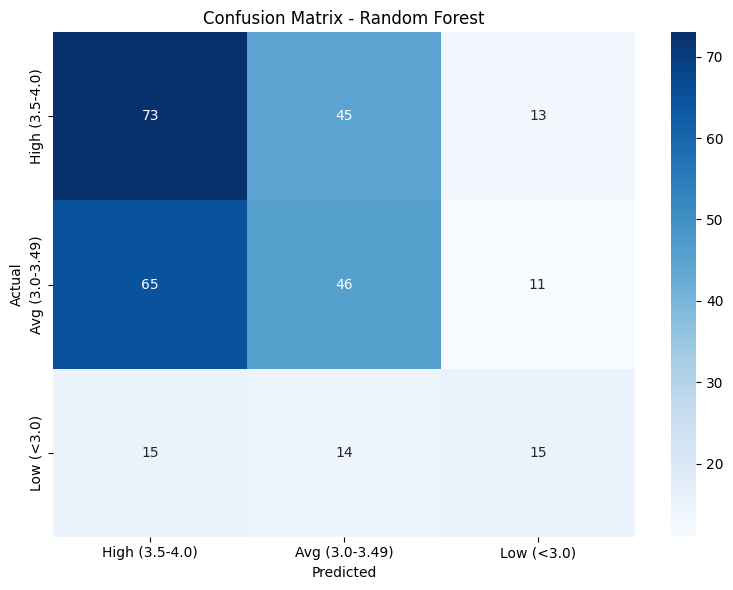


Classification Report - Random Forest
                precision    recall  f1-score   support

High (3.5-4.0)       0.48      0.56      0.51       131
Avg (3.0-3.49)       0.44      0.38      0.41       122
    Low (<3.0)       0.38      0.34      0.36        44

      accuracy                           0.45       297
     macro avg       0.43      0.43      0.43       297
  weighted avg       0.45      0.45      0.45       297



In [18]:
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')
print_classification_report(y_test, y_pred_rf, 'Random Forest')

---

## 6. Model 2: Gradient Boosting Classifier


In [19]:
print("Training Gradient Boosting Classifier...")

gb_model = GradientBoostingClassifier(
    n_estimators=300,          # 100 -> 300
    max_depth=6,               # 5 -> 6
    learning_rate=0.05,        # 0.1 -> 0.05
    min_samples_split=5,       # NEW (default is 2)
    min_samples_leaf=3,        # NEW (default is 1)
    subsample=0.8,             # NEW (stochastic GB)
    max_features='sqrt',       # NEW (feature sampling)
    validation_fraction=0.1,   # NEW (early stopping data)
    n_iter_no_change=20,       # NEW (early stopping patience)
    random_state=42
)

gb_model.fit(X_train, y_train)
result, y_pred_gb = evaluate_model(gb_model, X_test, y_test, 'Gradient Boosting')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation
evaluate_model_cv(gb_model, 'Gradient Boosting', X, y)

Training Gradient Boosting Classifier...

Results (Single 80/20 Split):
  Model: Gradient Boosting
  Accuracy: 0.4848
  Macro F1-Score: 0.4583
  Balanced Accuracy: 0.4572
  ROC-AUC: 0.63

5-Fold CV Results -- Gradient Boosting
  Accuracy:          0.5991 +/- 0.0258
  Macro F1-Score:    0.5988 +/- 0.0260
  Balanced Accuracy: 0.5952 +/- 0.0263
  ROC-AUC:           0.7840 +/- 0.0122


{'Model': 'Gradient Boosting',
 'CV Accuracy (mean)': np.float64(0.5991),
 'CV Accuracy (std)': np.float64(0.0258),
 'CV Macro F1 (mean)': np.float64(0.5988),
 'CV Macro F1 (std)': np.float64(0.026),
 'CV Balanced Acc (mean)': np.float64(0.5952),
 'CV Balanced Acc (std)': np.float64(0.0263),
 'CV ROC-AUC (mean)': np.float64(0.784),
 'CV ROC-AUC (std)': np.float64(0.0122)}

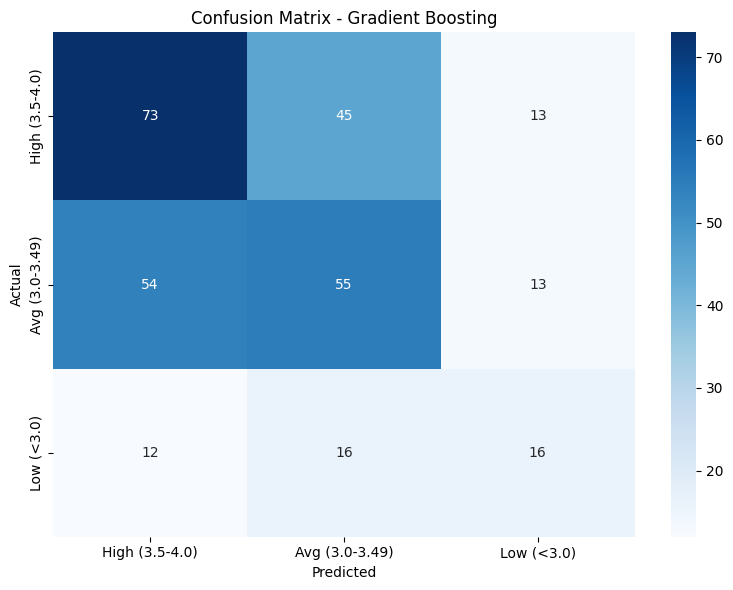


Classification Report - Gradient Boosting
                precision    recall  f1-score   support

High (3.5-4.0)       0.53      0.56      0.54       131
Avg (3.0-3.49)       0.47      0.45      0.46       122
    Low (<3.0)       0.38      0.36      0.37        44

      accuracy                           0.48       297
     macro avg       0.46      0.46      0.46       297
  weighted avg       0.48      0.48      0.48       297



In [20]:
plot_confusion_matrix(y_test, y_pred_gb, 'Gradient Boosting')
print_classification_report(y_test, y_pred_gb, 'Gradient Boosting')

---

## 7. Model 3: XGBoost Classifier


In [21]:
print("Training XGBoost Classifier...")

xgb_model = XGBClassifier(
    n_estimators=300,        # 100 -> 300
    max_depth=6,             # 5 -> 6
    learning_rate=0.05,      # 0.1 -> 0.05
    min_child_weight=3,      # NEW (prevent overfitting)
    subsample=0.8,           # NEW (row sampling)
    colsample_bytree=0.8,    # NEW (column sampling)
    gamma=1,                 # NEW (min loss reduction)
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
result, y_pred_xgb = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation
evaluate_model_cv(xgb_model, 'XGBoost', X, y)

Training XGBoost Classifier...

Results (Single 80/20 Split):
  Model: XGBoost
  Accuracy: 0.5051
  Macro F1-Score: 0.4926
  Balanced Accuracy: 0.4878
  ROC-AUC: 0.621

5-Fold CV Results -- XGBoost
  Accuracy:          0.5789 +/- 0.0130
  Macro F1-Score:    0.5790 +/- 0.0096
  Balanced Accuracy: 0.5744 +/- 0.0132
  ROC-AUC:           0.7783 +/- 0.0102


{'Model': 'XGBoost',
 'CV Accuracy (mean)': np.float64(0.5789),
 'CV Accuracy (std)': np.float64(0.013),
 'CV Macro F1 (mean)': np.float64(0.579),
 'CV Macro F1 (std)': np.float64(0.0096),
 'CV Balanced Acc (mean)': np.float64(0.5744),
 'CV Balanced Acc (std)': np.float64(0.0132),
 'CV ROC-AUC (mean)': np.float64(0.7783),
 'CV ROC-AUC (std)': np.float64(0.0102)}

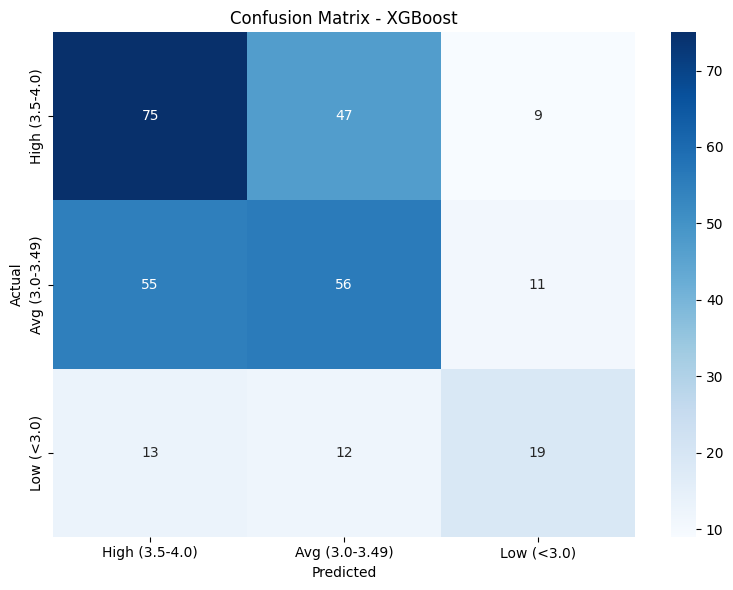


Classification Report - XGBoost
                precision    recall  f1-score   support

High (3.5-4.0)       0.52      0.57      0.55       131
Avg (3.0-3.49)       0.49      0.46      0.47       122
    Low (<3.0)       0.49      0.43      0.46        44

      accuracy                           0.51       297
     macro avg       0.50      0.49      0.49       297
  weighted avg       0.50      0.51      0.50       297



In [22]:
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost')
print_classification_report(y_test, y_pred_xgb, 'XGBoost')

---

## 8. Model 4: CatBoost Classifier


In [23]:
print("Training CatBoost Classifier...")

catboost_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=False
)

catboost_model.fit(X_train, y_train)
result, y_pred_cat = evaluate_model(catboost_model, X_test, y_test, 'CatBoost')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation
evaluate_model_cv(catboost_model, 'CatBoost', X, y)

Training CatBoost Classifier...

Results (Single 80/20 Split):
  Model: CatBoost
  Accuracy: 0.4848
  Macro F1-Score: 0.4705
  Balanced Accuracy: 0.4716
  ROC-AUC: 0.6141

5-Fold CV Results -- CatBoost
  Accuracy:          0.5854 +/- 0.0142
  Macro F1-Score:    0.5798 +/- 0.0134
  Balanced Accuracy: 0.5808 +/- 0.0147
  ROC-AUC:           0.7825 +/- 0.0097


{'Model': 'CatBoost',
 'CV Accuracy (mean)': np.float64(0.5854),
 'CV Accuracy (std)': np.float64(0.0142),
 'CV Macro F1 (mean)': np.float64(0.5798),
 'CV Macro F1 (std)': np.float64(0.0134),
 'CV Balanced Acc (mean)': np.float64(0.5808),
 'CV Balanced Acc (std)': np.float64(0.0147),
 'CV ROC-AUC (mean)': np.float64(0.7825),
 'CV ROC-AUC (std)': np.float64(0.0097)}

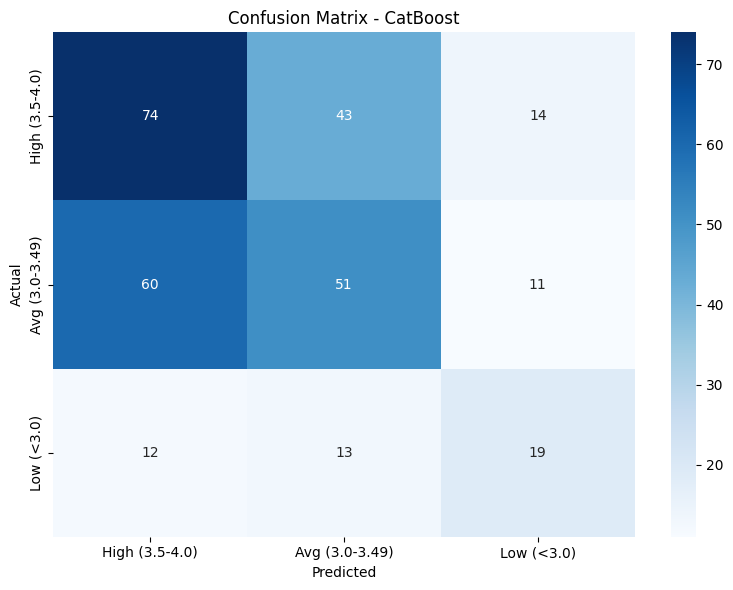


Classification Report - CatBoost
                precision    recall  f1-score   support

High (3.5-4.0)       0.51      0.56      0.53       131
Avg (3.0-3.49)       0.48      0.42      0.45       122
    Low (<3.0)       0.43      0.43      0.43        44

      accuracy                           0.48       297
     macro avg       0.47      0.47      0.47       297
  weighted avg       0.48      0.48      0.48       297



In [24]:
plot_confusion_matrix(y_test, y_pred_cat, 'CatBoost')
print_classification_report(y_test, y_pred_cat, 'CatBoost')

---

## 9. Model 5: Logistic Regression


In [25]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=2000,             # 1000 -> 2000
    C=0.5,                     # NEW (less regularization, default is 1.0)
    penalty='elasticnet',      # NEW (L1 + L2 combined)
    solver='saga',             # lbfgs -> saga (supports elasticnet)
    l1_ratio=0.5,              # NEW (balance between L1 and L2)
    multi_class='multinomial',
    class_weight='balanced',   # NEW (handle class imbalance)
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
result, y_pred_lr = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation
evaluate_model_cv(lr_model, 'Logistic Regression', X, y)

Training Logistic Regression...

Results (Single 80/20 Split):
  Model: Logistic Regression
  Accuracy: 0.4478
  Macro F1-Score: 0.4251
  Balanced Accuracy: 0.4389
  ROC-AUC: 0.6141

5-Fold CV Results -- Logistic Regression
  Accuracy:          0.5313 +/- 0.0180
  Macro F1-Score:    0.5216 +/- 0.0139
  Balanced Accuracy: 0.5288 +/- 0.0175
  ROC-AUC:           0.7410 +/- 0.0082


{'Model': 'Logistic Regression',
 'CV Accuracy (mean)': np.float64(0.5313),
 'CV Accuracy (std)': np.float64(0.018),
 'CV Macro F1 (mean)': np.float64(0.5216),
 'CV Macro F1 (std)': np.float64(0.0139),
 'CV Balanced Acc (mean)': np.float64(0.5288),
 'CV Balanced Acc (std)': np.float64(0.0175),
 'CV ROC-AUC (mean)': np.float64(0.741),
 'CV ROC-AUC (std)': np.float64(0.0082)}

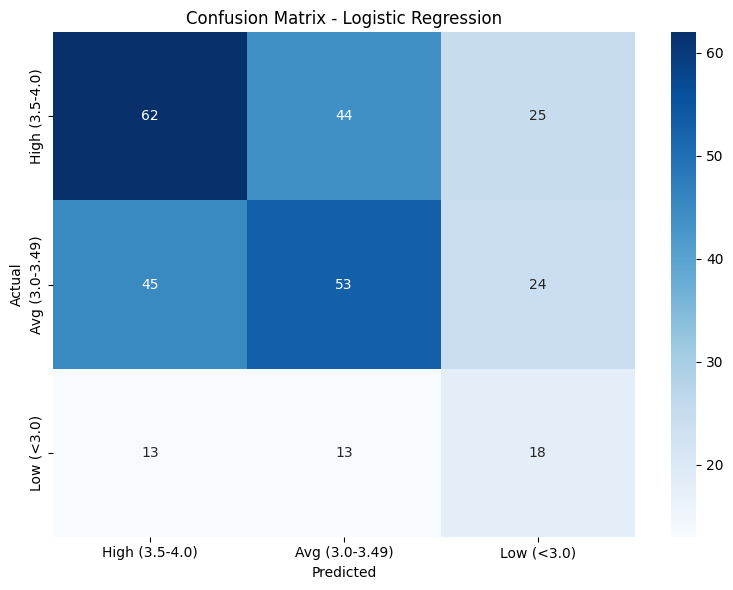


Classification Report - Logistic Regression
                precision    recall  f1-score   support

High (3.5-4.0)       0.52      0.47      0.49       131
Avg (3.0-3.49)       0.48      0.43      0.46       122
    Low (<3.0)       0.27      0.41      0.32        44

      accuracy                           0.45       297
     macro avg       0.42      0.44      0.43       297
  weighted avg       0.47      0.45      0.45       297



In [26]:
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression')
print_classification_report(y_test, y_pred_lr, 'Logistic Regression')

---

## 10. Model 6: Artificial Neural Network (PyTorch)

This is the sixth model in the corrected 80/20 experiment. Like the other five models, it is trained on the augmented training data and evaluated only on the 297 untouched real test observations.

The inherited CV helper below is retained for reference and is not leakage-corrected in this notebook.


In [27]:
# Define Neural Network Architecture
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super(NeuralNetwork, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

print("Neural Network class defined.")

Neural Network class defined.


In [28]:
# NEW: 5-Fold CV helper for the PyTorch ANN
def evaluate_ann_cv(X, y, cv=cv_strategy, hidden_sizes=[128, 64, 32],
                     epochs=100, batch_size=32, lr=0.001):
    """
    Manual 5-fold Stratified CV for the PyTorch ANN. A FRESH NeuralNetwork
    instance is trained from scratch on each fold's training portion and
    evaluated on that fold's held-out portion. Results are appended to the
    same shared cv_results list used by the other models.
    """
    fold_accuracies, fold_f1s, fold_bals, fold_aucs = [], [], [], []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        X_tr_t = torch.FloatTensor(X_tr).to(device)
        y_tr_t = torch.LongTensor(y_tr).to(device)
        X_val_t = torch.FloatTensor(X_val).to(device)

        fold_train_ds = TensorDataset(X_tr_t, y_tr_t)
        fold_train_loader = DataLoader(fold_train_ds, batch_size=batch_size, shuffle=True)

        fold_model = NeuralNetwork(X.shape[1], hidden_sizes, num_classes=3).to(device)
        fold_criterion = nn.CrossEntropyLoss()
        fold_optimizer = optim.Adam(fold_model.parameters(), lr=lr)

        fold_model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in fold_train_loader:
                fold_optimizer.zero_grad()
                outputs = fold_model(batch_X)
                loss = fold_criterion(outputs, batch_y)
                loss.backward()
                fold_optimizer.step()

        fold_model.eval()
        with torch.no_grad():
            outputs = fold_model(X_val_t)
            _, y_pred_fold = torch.max(outputs, 1)
            y_pred_fold = y_pred_fold.cpu().numpy()
            y_prob_fold = torch.softmax(outputs, dim=1).cpu().numpy()

        fold_accuracies.append(accuracy_score(y_val, y_pred_fold))
        fold_f1s.append(f1_score(y_val, y_pred_fold, average='macro'))
        fold_bals.append(balanced_accuracy_score(y_val, y_pred_fold))
        fold_aucs.append(roc_auc_score(y_val, y_prob_fold, multi_class='ovr', average='macro'))

        print(f"  Fold {fold_idx}/5 done -- Accuracy: {fold_accuracies[-1]:.4f}")

    result = {
        'Model': 'Neural Network',
        'CV Accuracy (mean)': round(float(np.mean(fold_accuracies)), 4),
        'CV Accuracy (std)': round(float(np.std(fold_accuracies)), 4),
        'CV Macro F1 (mean)': round(float(np.mean(fold_f1s)), 4),
        'CV Macro F1 (std)': round(float(np.std(fold_f1s)), 4),
        'CV Balanced Acc (mean)': round(float(np.mean(fold_bals)), 4),
        'CV Balanced Acc (std)': round(float(np.std(fold_bals)), 4),
        'CV ROC-AUC (mean)': round(float(np.mean(fold_aucs)), 4),
        'CV ROC-AUC (std)': round(float(np.std(fold_aucs)), 4),
    }
    cv_results.append(result)

    print(f"\n5-Fold CV Results -- Neural Network")
    print(f"  Accuracy:          {result['CV Accuracy (mean)']:.4f} +/- {result['CV Accuracy (std)']:.4f}")
    print(f"  Macro F1-Score:    {result['CV Macro F1 (mean)']:.4f} +/- {result['CV Macro F1 (std)']:.4f}")
    print(f"  Balanced Accuracy: {result['CV Balanced Acc (mean)']:.4f} +/- {result['CV Balanced Acc (std)']:.4f}")
    print(f"  ROC-AUC:           {result['CV ROC-AUC (mean)']:.4f} +/- {result['CV ROC-AUC (std)']:.4f}")

    return result

print("evaluate_ann_cv() ready.")

evaluate_ann_cv() ready.


In [29]:
# Prepare data for PyTorch (single 80/20 split)
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model
input_size = X_train.shape[1]
hidden_sizes = [128, 64, 32]
num_classes = 3

ann_model = NeuralNetwork(input_size, hidden_sizes, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ann_model.parameters(), lr=0.001)

print(f"Model architecture:")
print(ann_model)

Model architecture:
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [30]:
# Training loop (single 80/20 split)
print("Training Neural Network...")
epochs = 100
train_losses = []

for epoch in range(epochs):
    ann_model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = ann_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}")

print("\nTraining completed!")

Training Neural Network...
Epoch [20/100], Loss: 0.7865
Epoch [40/100], Loss: 0.6859
Epoch [60/100], Loss: 0.6066
Epoch [80/100], Loss: 0.5295
Epoch [100/100], Loss: 0.5260

Training completed!


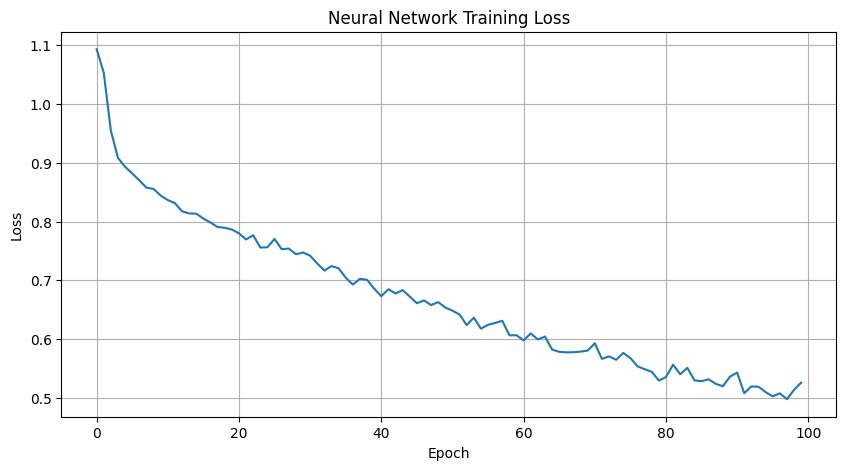

In [31]:
# Plot training loss (inline only -- not saved)
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [32]:
# Evaluate Neural Network (single 80/20 split)
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    _, y_pred_ann = torch.max(outputs, 1)
    y_pred_ann = y_pred_ann.cpu().numpy()

    # Get probabilities for ROC-AUC
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_ann)
macro_f1 = f1_score(y_test, y_pred_ann, average='macro')
balanced_acc = balanced_accuracy_score(y_test, y_pred_ann)
roc_auc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

result = {
    'Model': 'Neural Network',
    'Accuracy': round(accuracy, 4),
    'Macro F1-Score': round(macro_f1, 4),
    'Balanced Accuracy': round(balanced_acc, 4),
    'ROC-AUC': round(roc_auc, 4)
}
all_results.append(result)

print(f"\nNeural Network Results (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation (manual PyTorch loop, ~5x the training time above)
evaluate_ann_cv(X, y)


Neural Network Results (Single 80/20 Split):
  Model: Neural Network
  Accuracy: 0.4444
  Macro F1-Score: 0.4237
  Balanced Accuracy: 0.4349
  ROC-AUC: 0.6068
  Fold 1/5 done -- Accuracy: 0.5700
  Fold 2/5 done -- Accuracy: 0.5440
  Fold 3/5 done -- Accuracy: 0.5570
  Fold 4/5 done -- Accuracy: 0.5537
  Fold 5/5 done -- Accuracy: 0.5425

5-Fold CV Results -- Neural Network
  Accuracy:          0.5534 +/- 0.0100
  Macro F1-Score:    0.5506 +/- 0.0111
  Balanced Accuracy: 0.5517 +/- 0.0100
  ROC-AUC:           0.7452 +/- 0.0103


{'Model': 'Neural Network',
 'CV Accuracy (mean)': 0.5534,
 'CV Accuracy (std)': 0.01,
 'CV Macro F1 (mean)': 0.5506,
 'CV Macro F1 (std)': 0.0111,
 'CV Balanced Acc (mean)': 0.5517,
 'CV Balanced Acc (std)': 0.01,
 'CV ROC-AUC (mean)': 0.7452,
 'CV ROC-AUC (std)': 0.0103}

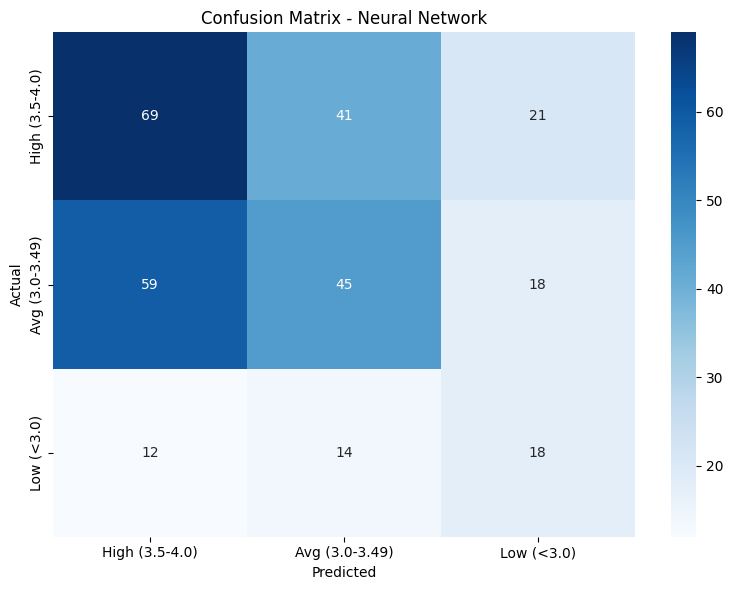


Classification Report - Neural Network
                precision    recall  f1-score   support

High (3.5-4.0)       0.49      0.53      0.51       131
Avg (3.0-3.49)       0.45      0.37      0.41       122
    Low (<3.0)       0.32      0.41      0.36        44

      accuracy                           0.44       297
     macro avg       0.42      0.43      0.42       297
  weighted avg       0.45      0.44      0.44       297



In [33]:
plot_confusion_matrix(y_test, y_pred_ann, 'Neural Network')
print_classification_report(y_test, y_pred_ann, 'Neural Network')

---

## 11. Model Comparison -- Corrected Single 80/20 Split

The primary comparison below uses predictions from models trained on the augmented training data and evaluated only on the 297 untouched real test observations. These are the corrected 80/20 results; the inherited 5-fold CV analysis is reported separately and is not leakage-corrected.


In [34]:
# Create comparison dataframe (single split)
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("="*80)
print("MODEL COMPARISON - Single 80/20 Split - Balanced Normalized Data (GAN Augmented)")
print("="*80)
print(results_df.to_string(index=False))

MODEL COMPARISON - Single 80/20 Split - Balanced Normalized Data (GAN Augmented)
              Model  Accuracy  Macro F1-Score  Balanced Accuracy  ROC-AUC
            XGBoost    0.5051          0.4926             0.4878   0.6210
  Gradient Boosting    0.4848          0.4583             0.4572   0.6300
           CatBoost    0.4848          0.4705             0.4716   0.6141
      Random Forest    0.4512          0.4269             0.4251   0.6059
Logistic Regression    0.4478          0.4251             0.4389   0.6141
     Neural Network    0.4444          0.4237             0.4349   0.6068


## 12. Inherited 5-Fold Cross-Validation (Not Leakage-Corrected)

This analysis is retained from the previous notebook for reference. It is separate from the corrected 80/20 evaluation and must not be treated as leakage-safe, train-only CTGAN CV, final validation, or the primary performance estimate. A separate leakage-safe 5-fold CV analysis will be performed later.


In [35]:
import os
print(os.getcwd())

c:\Research\Sleep_Pattern_Academic_Engagement\notebooks


In [36]:
# Create comparison dataframe (5-fold CV)
cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values('CV Accuracy (mean)', ascending=False).reset_index(drop=True)

print("="*100)
print("MODEL COMPARISON - 5-Fold Stratified Cross-Validation - Balanced Normalized Data (GAN Augmented)")
print("="*100)
print(cv_results_df.to_string(index=False))

# Save results to CSV (metrics table only -- no images saved anywhere in this notebook)
cv_results_df.to_csv('../results/balanced_normalized_5fold_cv_results.csv', index=False)
print("\nCV results table saved to: ../results/balanced_normalized_5fold_cv_results.csv")

MODEL COMPARISON - 5-Fold Stratified Cross-Validation - Balanced Normalized Data (GAN Augmented)
              Model  CV Accuracy (mean)  CV Accuracy (std)  CV Macro F1 (mean)  CV Macro F1 (std)  CV Balanced Acc (mean)  CV Balanced Acc (std)  CV ROC-AUC (mean)  CV ROC-AUC (std)
  Gradient Boosting              0.5991             0.0258              0.5988             0.0260                  0.5952                 0.0263             0.7840            0.0122
           CatBoost              0.5854             0.0142              0.5798             0.0134                  0.5808                 0.0147             0.7825            0.0097
            XGBoost              0.5789             0.0130              0.5790             0.0096                  0.5744                 0.0132             0.7783            0.0102
      Random Forest              0.5756             0.0116              0.5738             0.0129                  0.5709                 0.0115             0.7800            

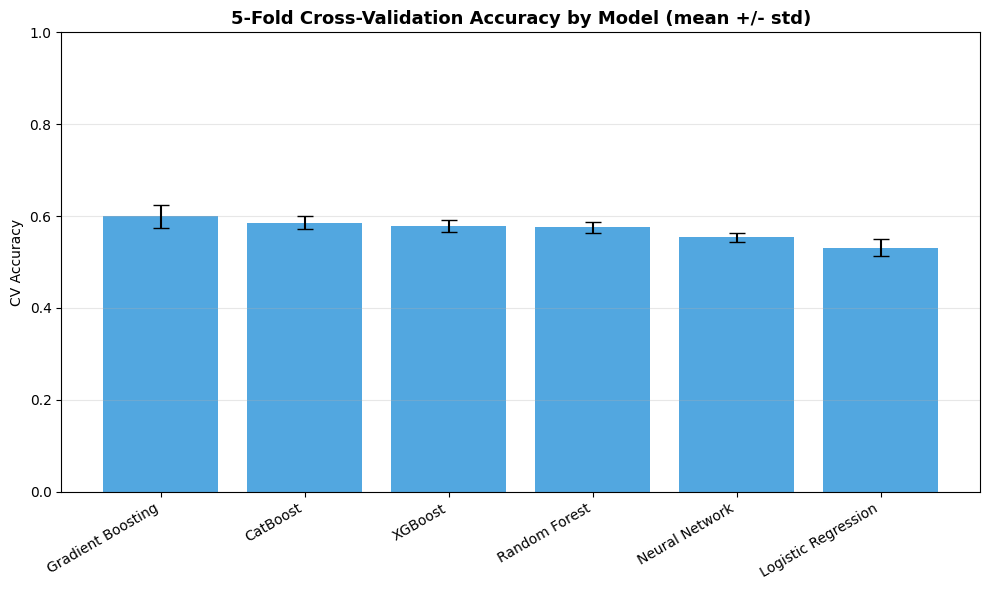

In [37]:
# Visualize CV Accuracy with error bars (inline only -- NOT saved to disk)
plt.figure(figsize=(10, 6))
plt.bar(
    cv_results_df['Model'],
    cv_results_df['CV Accuracy (mean)'],
    yerr=cv_results_df['CV Accuracy (std)'],
    capsize=6,
    color='#3498db',
    alpha=0.85
)
plt.title('5-Fold Cross-Validation Accuracy by Model (mean +/- std)', fontsize=13, fontweight='bold')
plt.ylabel('CV Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

## 14. Feature Importance Visualization

Visualizing which features contribute most to predictions for each model.


In [38]:
# Get feature importances from tree-based models
feature_importance_dict = {}

# Random Forest
feature_importance_dict['Random Forest'] = rf_model.feature_importances_

# Gradient Boosting
feature_importance_dict['Gradient Boosting'] = gb_model.feature_importances_

# XGBoost
feature_importance_dict['XGBoost'] = xgb_model.feature_importances_

# CatBoost
feature_importance_dict['CatBoost'] = catboost_model.feature_importances_

# Logistic Regression (use absolute coefficients averaged across classes)
lr_importance = np.mean(np.abs(lr_model.coef_), axis=0)
lr_importance = lr_importance / lr_importance.sum()  # Normalize
feature_importance_dict['Logistic Regression'] = lr_importance

print("Feature importances extracted for all models!")

Feature importances extracted for all models!


In [39]:
# Create feature importance dataframe
importance_df = pd.DataFrame(feature_importance_dict, index=feature_cols)
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print("Top 15 Most Important Features (Averaged across models):")
print("="*60)
print(importance_df['Average'].head(15).to_string())
print("\nBottom 5 Least Important Features:")
print(importance_df['Average'].tail(5).to_string())

Top 15 Most Important Features (Averaged across models):
Holiday_Bed_Time                      2.593904
Focus_on_Academic_Task                2.182336
Impact_of_Sleep_on_Academic           1.584587
Main_Reason_for_Insufficient_Sleep    1.414194
Struggle_to_Sleep                     1.406797
Sleepiness_During_Class               1.276030
AVG_Sleep_Per_Night                   1.241849
Rate_Sleep_Quality                    1.096365
Daytime_Nap                           1.044801
Where_live                            0.900641
Exam_Night_Bed_Time                   0.759193
Daily_Academics_Time_Spend            0.741733
Class_Attendance                      0.656621
Age                                   0.463524
Consume_Caffeine_Night                0.412580

Bottom 5 Least Important Features:
Use_Sleep_Tracking_Devices        0.151609
Sacrifices_Sleep_for_Academics    0.138872
Holiday_WakeUp_Time               0.089378
Sleep_Affecting_Drugs             0.069887
Electronic_Devices_Before_Bed 

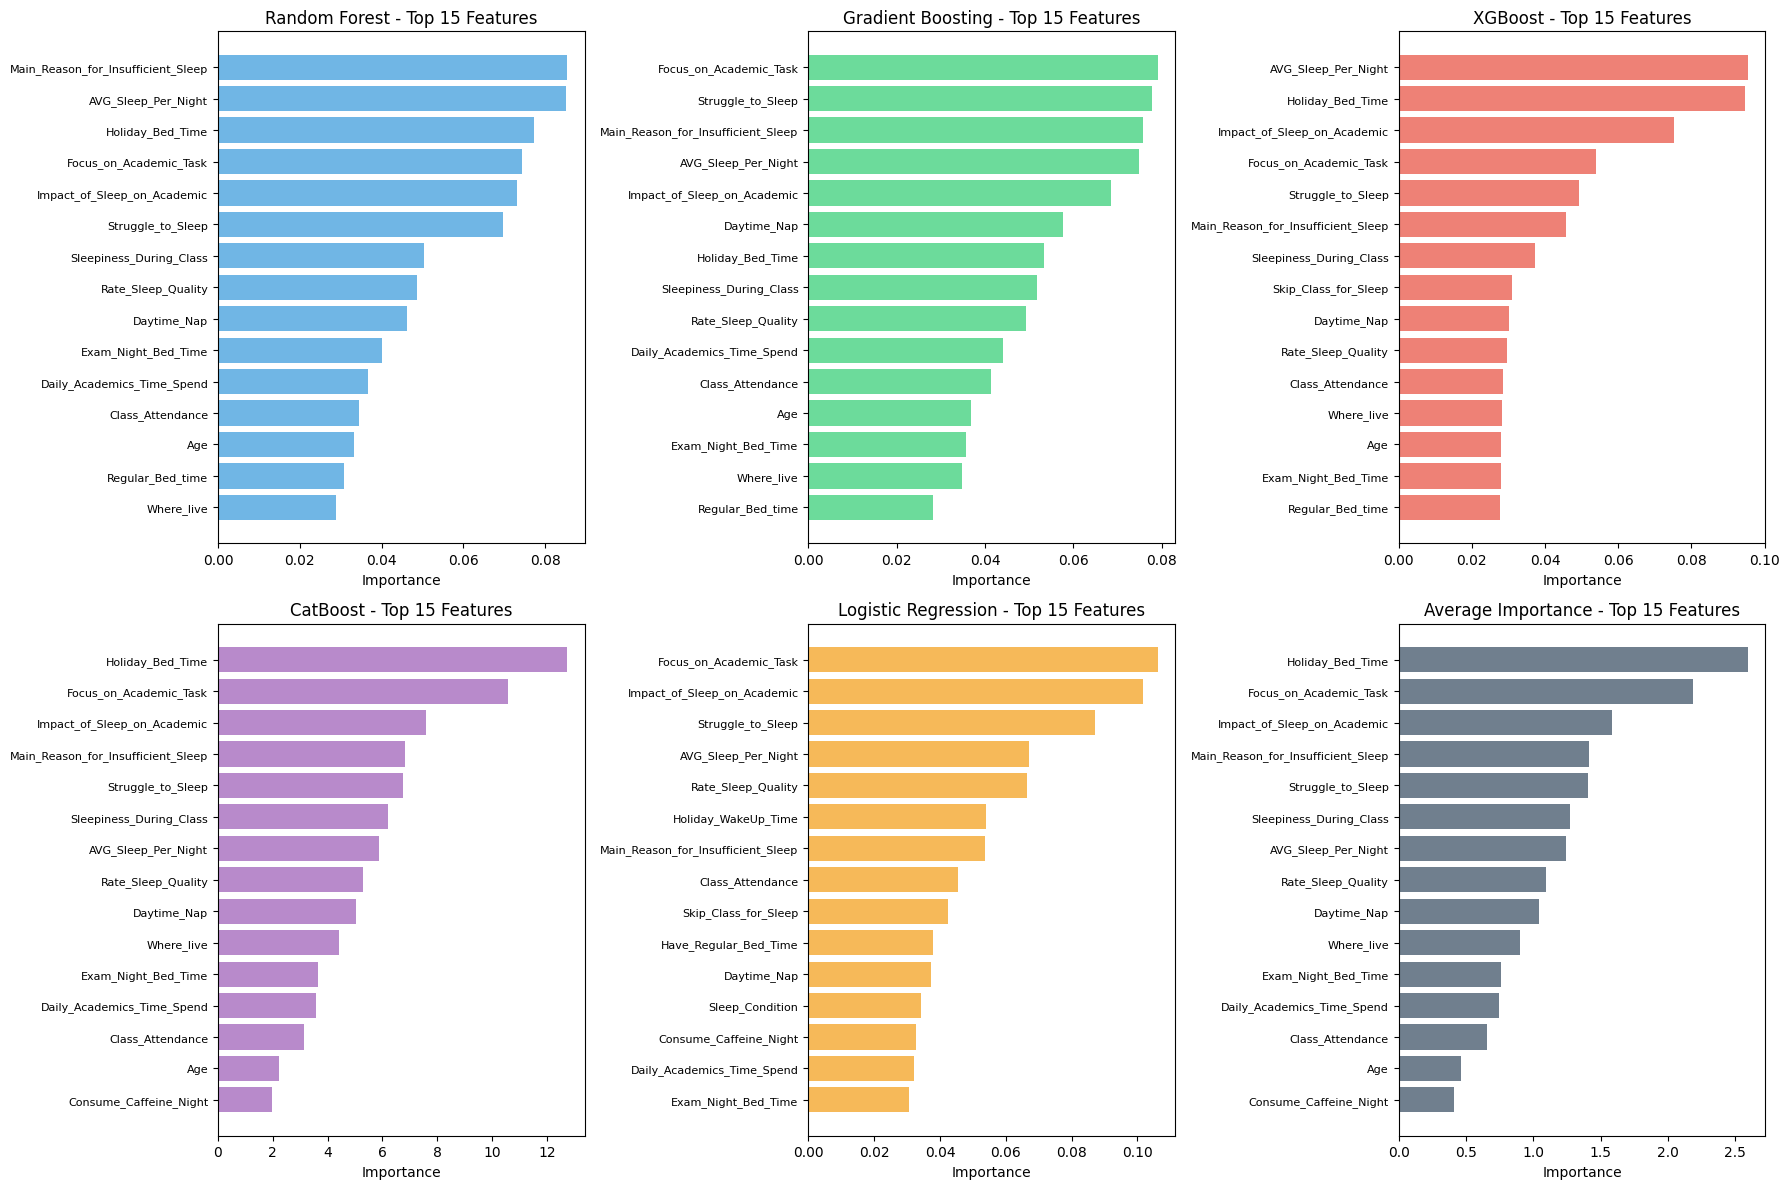

In [40]:
# Visualize feature importance for each model (inline only -- not saved)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
models_to_plot = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'CatBoost', 'Logistic Regression']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for idx, (ax, model_name, color) in enumerate(zip(axes.flat[:5], models_to_plot, colors)):
    # Get top 15 features for this model
    model_importance = importance_df[model_name].sort_values(ascending=True).tail(15)

    ax.barh(model_importance.index, model_importance.values, color=color, alpha=0.7)
    ax.set_xlabel('Importance')
    ax.set_title(f'{model_name} - Top 15 Features')
    ax.tick_params(axis='y', labelsize=8)

# Average importance in the last subplot
ax = axes.flat[5]
avg_importance = importance_df['Average'].sort_values(ascending=True).tail(15)
ax.barh(avg_importance.index, avg_importance.values, color='#34495e', alpha=0.7)
ax.set_xlabel('Importance')
ax.set_title('Average Importance - Top 15 Features')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

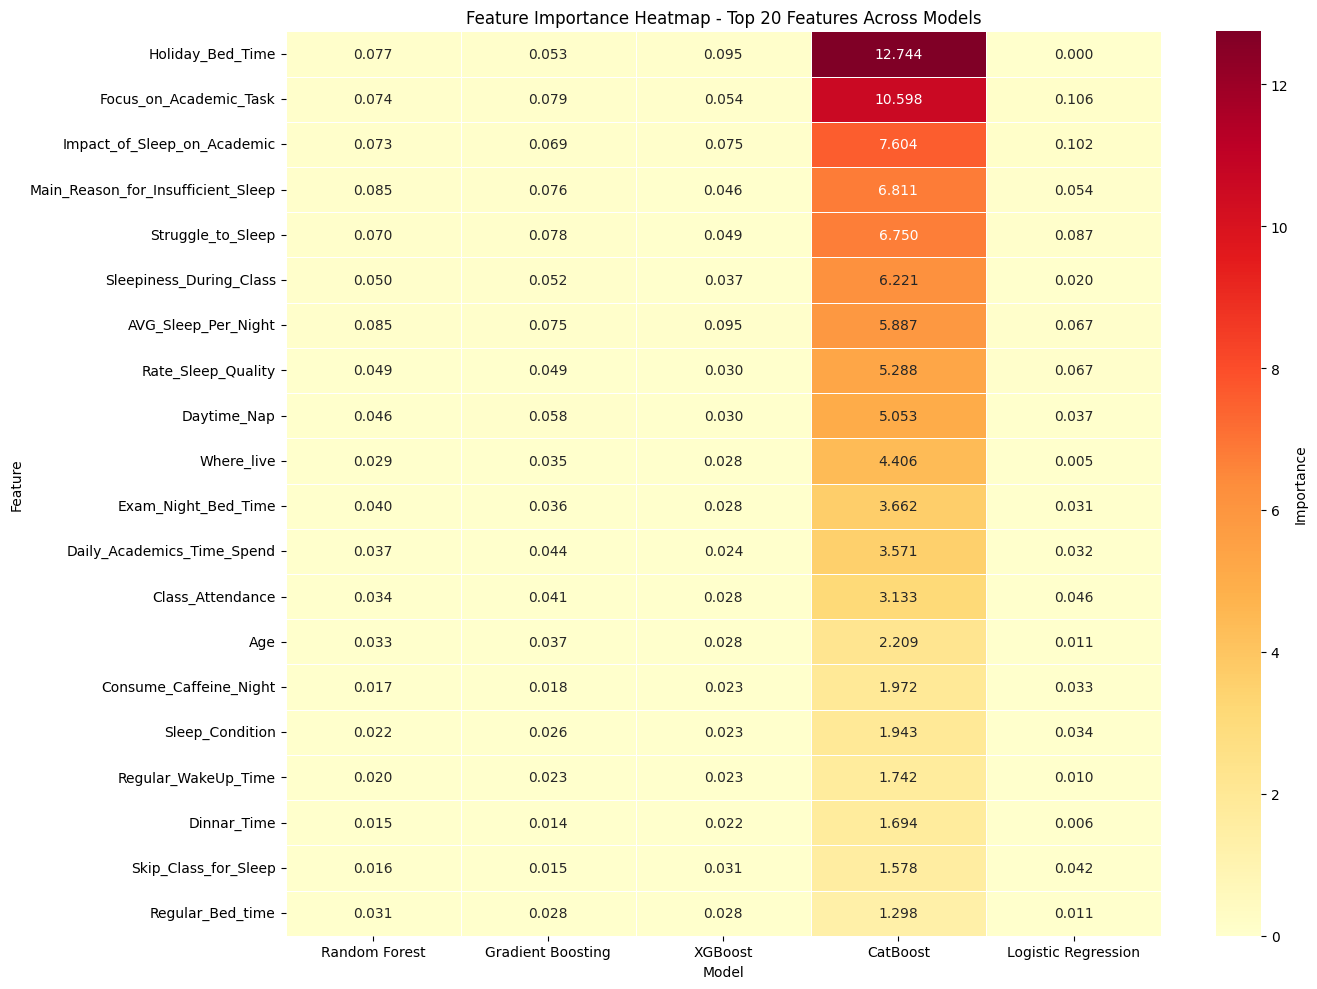

In [41]:
# Heatmap of feature importance across all models (inline only -- not saved)
plt.figure(figsize=(14, 10))

# Get top 20 features by average importance
top_features = importance_df['Average'].sort_values(ascending=False).head(20).index
heatmap_data = importance_df.loc[top_features, models_to_plot]

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Importance'})
plt.title('Feature Importance Heatmap - Top 20 Features Across Models')
plt.xlabel('Model')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [42]:
# Save feature importance to CSV (data only -- no images saved)
importance_df.to_csv('../results/feature_importance_all_models.csv')
print("Feature importance saved to: ../results/feature_importance_all_models.csv")

# Summary of most important features
print("\n" + "="*60)
print("FEATURE IMPORTANCE SUMMARY")
print("="*60)
print("\nTop 10 Most Influential Features (by average importance):")
for i, (feature, importance) in enumerate(importance_df['Average'].head(10).items(), 1):
    print(f"  {i}. {feature}: {importance:.4f}")

Feature importance saved to: ../results/feature_importance_all_models.csv

FEATURE IMPORTANCE SUMMARY

Top 10 Most Influential Features (by average importance):
  1. Holiday_Bed_Time: 2.5939
  2. Focus_on_Academic_Task: 2.1823
  3. Impact_of_Sleep_on_Academic: 1.5846
  4. Main_Reason_for_Insufficient_Sleep: 1.4142
  5. Struggle_to_Sleep: 1.4068
  6. Sleepiness_During_Class: 1.2760
  7. AVG_Sleep_Per_Night: 1.2418
  8. Rate_Sleep_Quality: 1.0964
  9. Daytime_Nap: 1.0448
  10. Where_live: 0.9006


## 15. Corrected 80/20 Model Performance Summary

This summary reports the six models' primary metrics on the 297 untouched real test observations after training on the augmented training data. It is separate from the inherited, not leakage-corrected 5-fold CV analysis.


In [43]:
# ============================================================================
# SIMPLE COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================================

from sklearn.metrics import precision_score, recall_score, roc_auc_score

print("Creating comprehensive model comparison table...\n")

# Store results for all models
all_model_results = []

# ===== 1. GRADIENT BOOSTING =====
gb_acc = accuracy_score(y_test, y_pred_gb)
gb_prec = precision_score(y_test, y_pred_gb, average='macro')
gb_rec = recall_score(y_test, y_pred_gb, average='macro')
gb_f1 = f1_score(y_test, y_pred_gb, average='macro')
gb_roc = roc_auc_score(y_test, gb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': round(gb_acc, 4),
    'Precision': round(gb_prec, 4),
    'Recall': round(gb_rec, 4),
    'F1-Score': round(gb_f1, 4),
    'ROC-AUC': round(gb_roc, 4)
})

# ===== 2. XGBOOST =====
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb, average='macro')
xgb_rec = recall_score(y_test, y_pred_xgb, average='macro')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
xgb_roc = roc_auc_score(y_test, xgb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'XGBoost',
    'Accuracy': round(xgb_acc, 4),
    'Precision': round(xgb_prec, 4),
    'Recall': round(xgb_rec, 4),
    'F1-Score': round(xgb_f1, 4),
    'ROC-AUC': round(xgb_roc, 4)
})

# ===== 3. CATBOOST =====
cb_acc = accuracy_score(y_test, y_pred_cat)
cb_prec = precision_score(y_test, y_pred_cat, average='macro')
cb_rec = recall_score(y_test, y_pred_cat, average='macro')
cb_f1 = f1_score(y_test, y_pred_cat, average='macro')
cb_roc = roc_auc_score(y_test, catboost_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'CatBoost',
    'Accuracy': round(cb_acc, 4),
    'Precision': round(cb_prec, 4),
    'Recall': round(cb_rec, 4),
    'F1-Score': round(cb_f1, 4),
    'ROC-AUC': round(cb_roc, 4)
})

# ===== 4. RANDOM FOREST =====
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_rec = recall_score(y_test, y_pred_rf, average='macro')
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_roc = roc_auc_score(y_test, rf_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Random Forest',
    'Accuracy': round(rf_acc, 4),
    'Precision': round(rf_prec, 4),
    'Recall': round(rf_rec, 4),
    'F1-Score': round(rf_f1, 4),
    'ROC-AUC': round(rf_roc, 4)
})

# ===== 5. LOGISTIC REGRESSION =====
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='macro')
lr_rec = recall_score(y_test, y_pred_lr, average='macro')
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
lr_roc = roc_auc_score(y_test, lr_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': round(lr_acc, 4),
    'Precision': round(lr_prec, 4),
    'Recall': round(lr_rec, 4),
    'F1-Score': round(lr_f1, 4),
    'ROC-AUC': round(lr_roc, 4)
})

# ===== 6. NEURAL NETWORK =====
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

ann_acc = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann, average='macro')
ann_rec = recall_score(y_test, y_pred_ann, average='macro')
ann_f1 = f1_score(y_test, y_pred_ann, average='macro')
ann_roc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Neural Network',
    'Accuracy': round(ann_acc, 4),
    'Precision': round(ann_prec, 4),
    'Recall': round(ann_rec, 4),
    'F1-Score': round(ann_f1, 4),
    'ROC-AUC': round(ann_roc, 4)
})

# Create DataFrame and sort by accuracy
final_comparison_df = pd.DataFrame(all_model_results)
final_comparison_df = final_comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Add rank
final_comparison_df.insert(0, 'Rank', range(1, len(final_comparison_df) + 1))

# Display table
print("=" * 95)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON (Single 80/20 Split)")
print("=" * 95)
print(final_comparison_df.to_string(index=False))
print("=" * 95)

# Summary
best_model = final_comparison_df.iloc[0]['Model']
best_acc = final_comparison_df.iloc[0]['Accuracy']

print(f"\n🏆 Best Model: {best_model}")
print(f"📊 Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"📈 Models Compared: {len(final_comparison_df)}")
print("=" * 95)

# Save results to CSV (data only -- no images saved)
final_comparison_df.to_csv('../results/corrected_80_20_model_comparison.csv', index=False)
print("\n✓ Results saved to: ../results/corrected_80_20_model_comparison.csv")

Creating comprehensive model comparison table...

COMPREHENSIVE MODEL PERFORMANCE COMPARISON (Single 80/20 Split)
 Rank               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    1             XGBoost    0.5051     0.4995  0.4878    0.4926   0.6210
    2   Gradient Boosting    0.4848     0.4601  0.4572    0.4583   0.6300
    3            CatBoost    0.4848     0.4718  0.4716    0.4705   0.6141
    4       Random Forest    0.4512     0.4333  0.4251    0.4269   0.6059
    5 Logistic Regression    0.4478     0.4224  0.4389    0.4251   0.6141
    6      Neural Network    0.4444     0.4195  0.4349    0.4237   0.6068

🏆 Best Model: XGBoost
📊 Best Accuracy: 0.5051 (50.51%)
📈 Models Compared: 6

✓ Results saved to: ../results/corrected_80_20_model_comparison.csv


## Extra Graphs


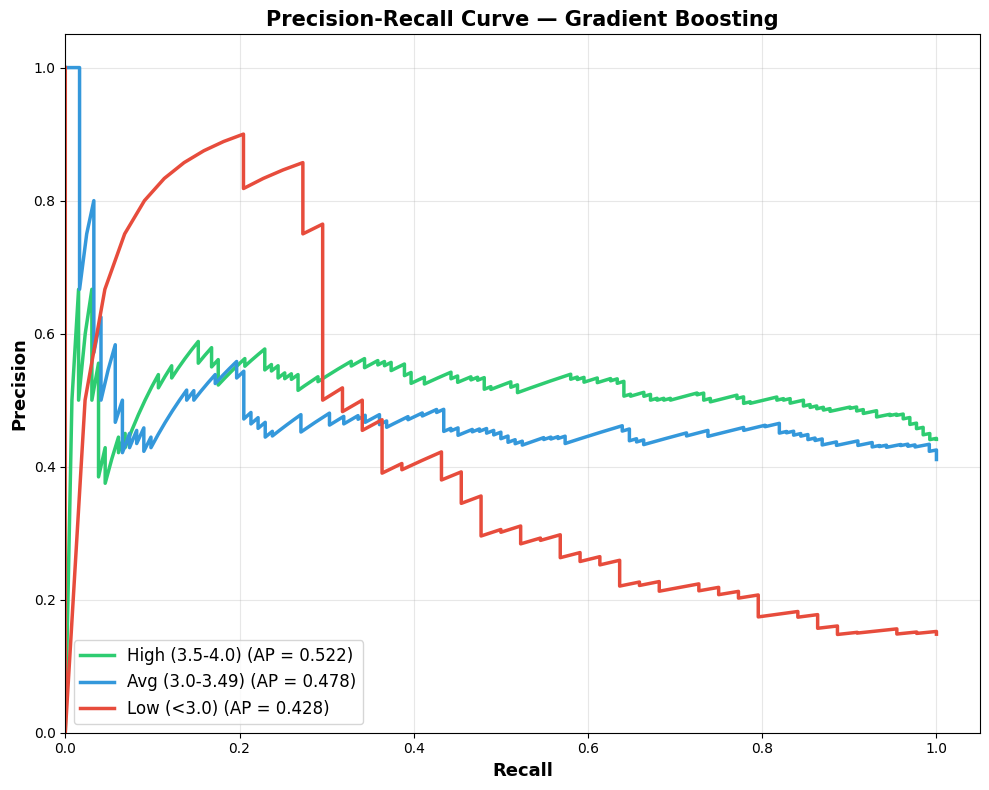

In [44]:
# ============================================================================
# PRECISION-RECALL CURVE - GRADIENT BOOSTING
# Top performer - Shows per-class precision vs recall tradeoff
# ============================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Binarize y_test for multi-class PR curve (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)']
colors = ['#2ecc71', '#3498db', '#e74c3c']

# Get predicted probabilities from Gradient Boosting model
gb_probs = gb_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 8))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], gb_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], gb_probs[:, i])
    ax.plot(recall, precision, color=color, linewidth=2.5, label=f'{cls} (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Curve — Gradient Boosting', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower left')
ax.set_xlim([0.0, 1.05]); ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

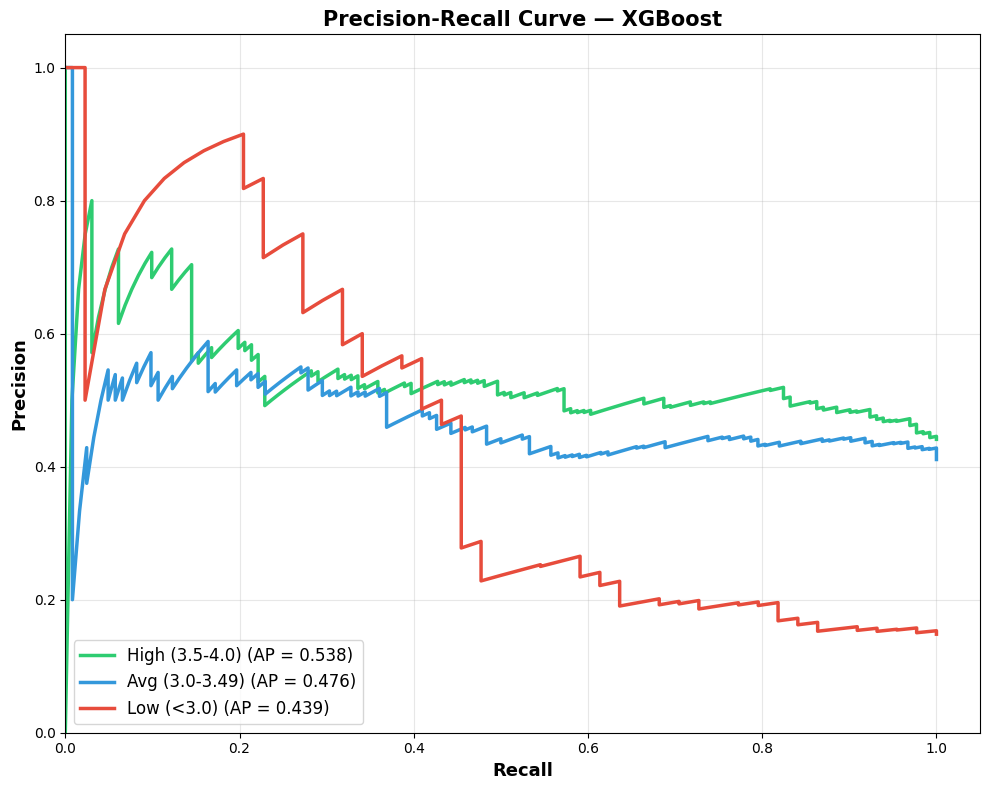

In [45]:
# ============================================================================
# PRECISION-RECALL CURVE - XGBOOST
# ============================================================================
xgb_probs = xgb_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 8))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], xgb_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], xgb_probs[:, i])
    ax.plot(recall, precision, color=color, linewidth=2.5, label=f'{cls} (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Curve — XGBoost', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower left')
ax.set_xlim([0.0, 1.05]); ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

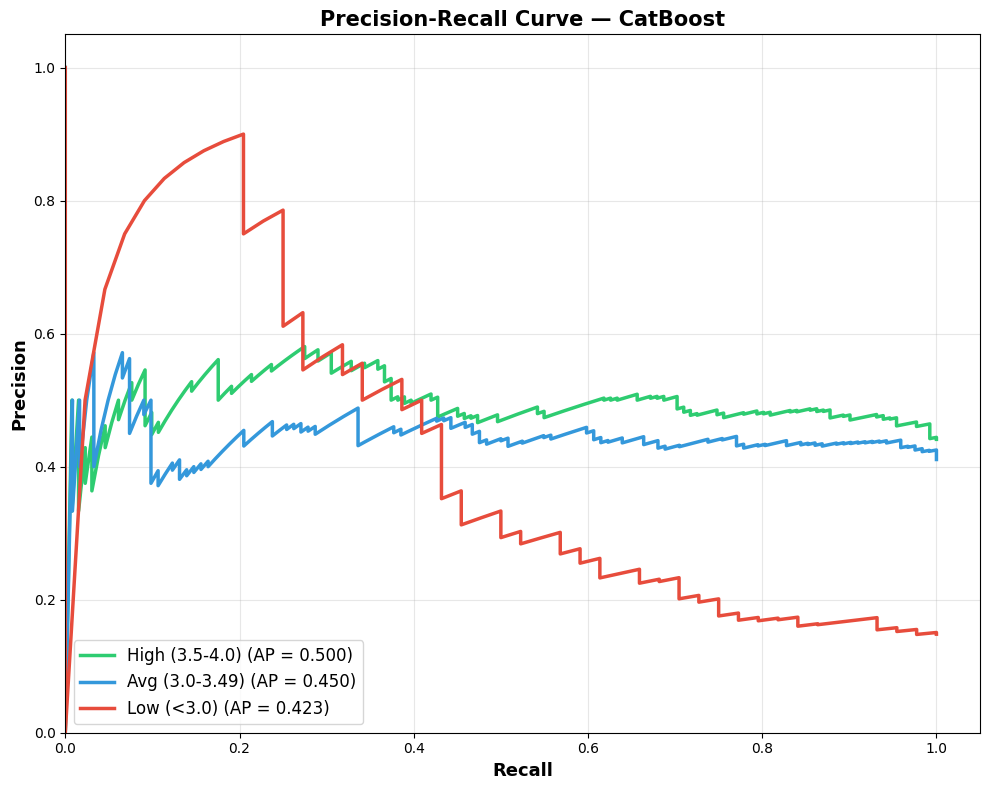

In [46]:
# ============================================================================
# PRECISION-RECALL CURVE - CATBOOST
# ============================================================================
cb_probs = catboost_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 8))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], cb_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], cb_probs[:, i])
    ax.plot(recall, precision, color=color, linewidth=2.5, label=f'{cls} (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Curve — CatBoost', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower left')
ax.set_xlim([0.0, 1.05]); ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

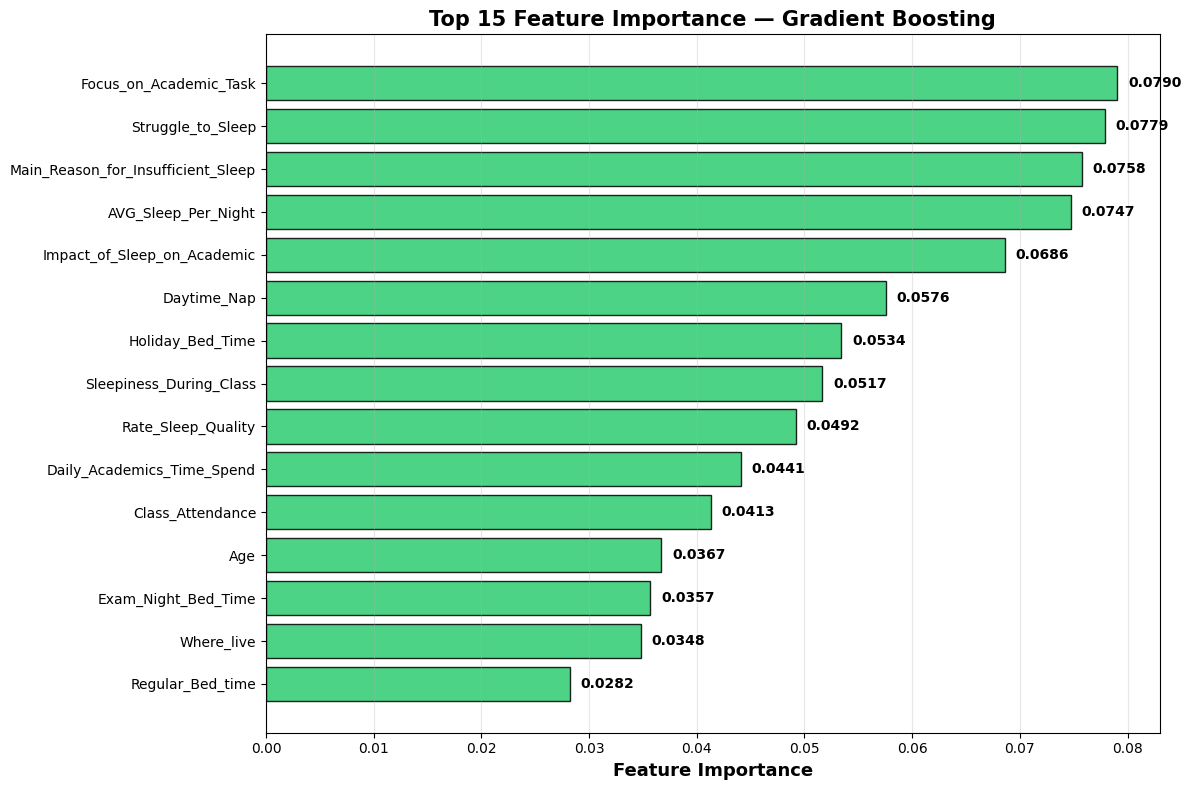

In [47]:
# ============================================================================
# TOP 15 FEATURE IMPORTANCE - GRADIENT BOOSTING (Gini importance)
# ============================================================================
gb_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': gb_model.feature_importances_}
                       ).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(gb_imp['Feature'], gb_imp['Importance'], color='#2ecc71', alpha=0.85, edgecolor='black')

for bar, val in zip(bars, gb_imp['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Importance', fontsize=13, fontweight='bold')
ax.set_title('Top 15 Feature Importance — Gradient Boosting', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

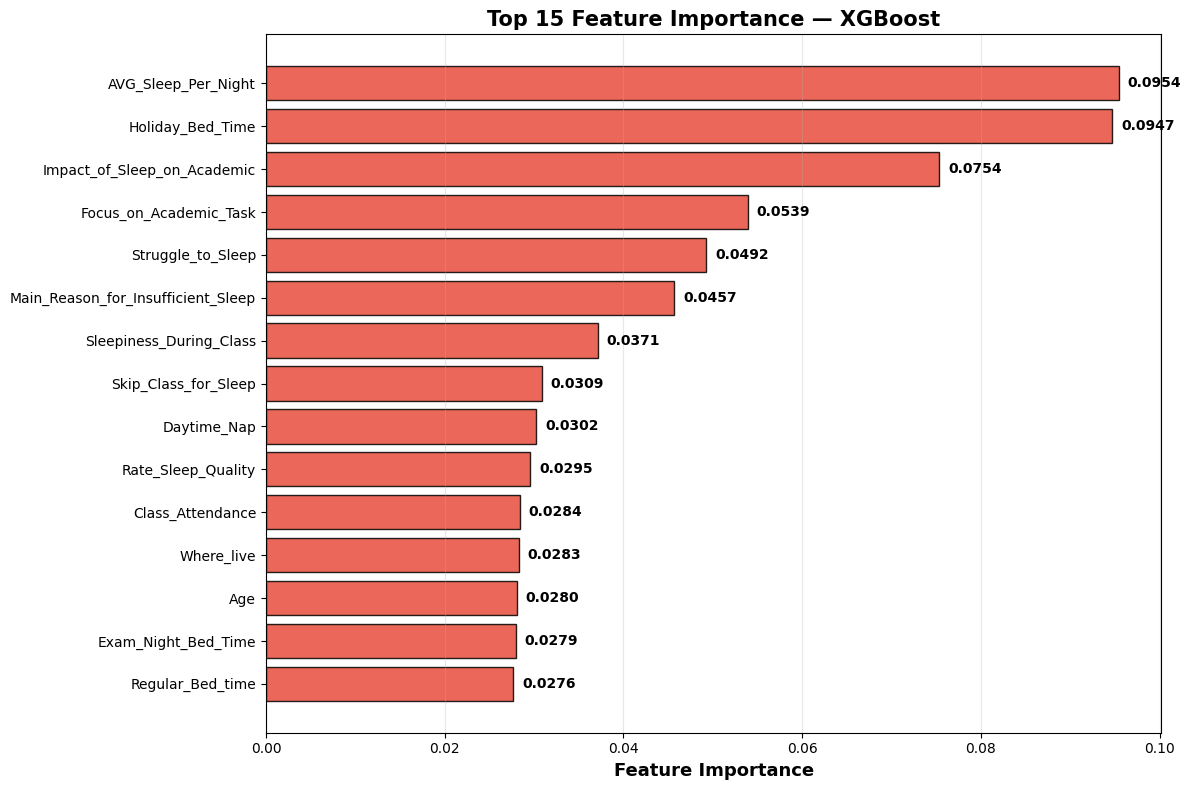

In [48]:
# ============================================================================
# TOP 15 FEATURE IMPORTANCE - XGBOOST (gain-based importance)
# ============================================================================
xgb_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': xgb_model.feature_importances_}
                        ).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(xgb_imp['Feature'], xgb_imp['Importance'], color='#e74c3c', alpha=0.85, edgecolor='black')

for bar, val in zip(bars, xgb_imp['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Importance', fontsize=13, fontweight='bold')
ax.set_title('Top 15 Feature Importance — XGBoost', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

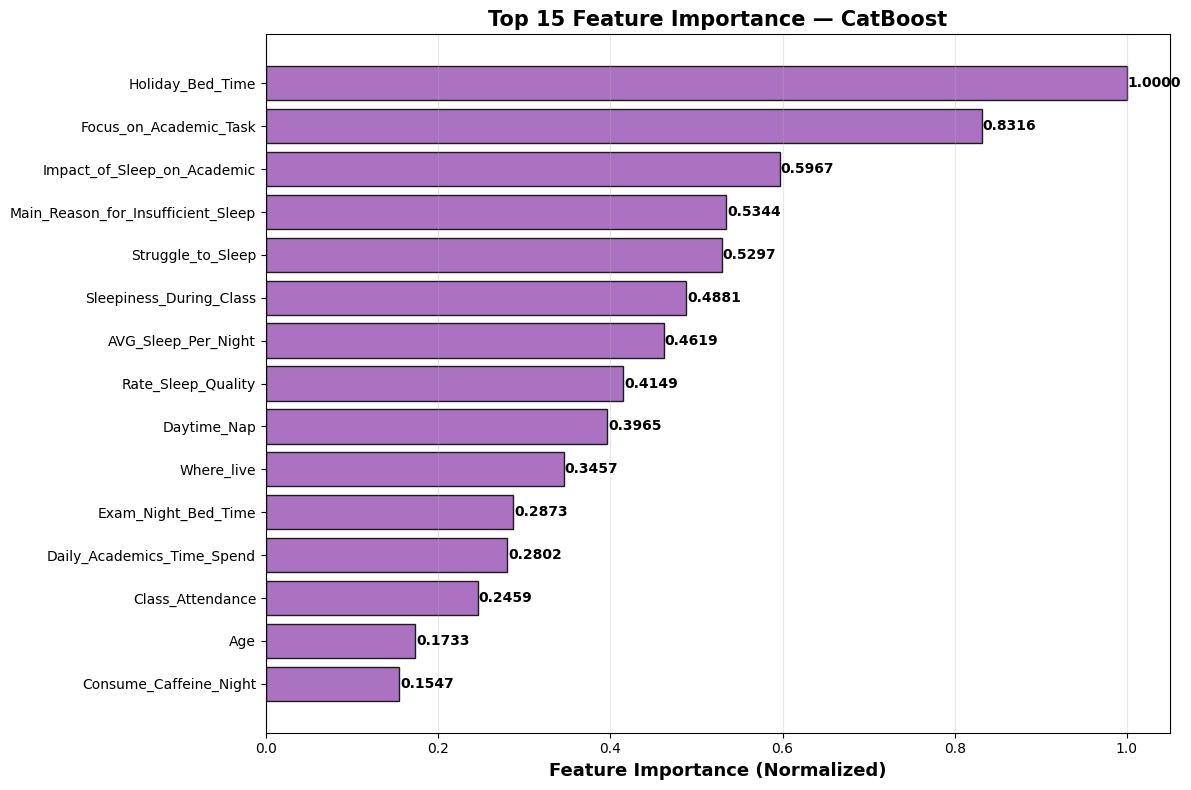

In [49]:
# ============================================================================
# TOP 15 FEATURE IMPORTANCE - CATBOOST (PredictionValuesChange, normalized)
# ============================================================================
cb_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': catboost_model.feature_importances_}
                       ).sort_values('Importance', ascending=True).tail(15)
cb_imp['Importance'] = cb_imp['Importance'] / cb_imp['Importance'].max()

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(cb_imp['Feature'], cb_imp['Importance'], color='#9b59b6', alpha=0.85, edgecolor='black')

for bar, val in zip(bars, cb_imp['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Importance (Normalized)', fontsize=13, fontweight='bold')
ax.set_title('Top 15 Feature Importance — CatBoost', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Extra Extra Graphs


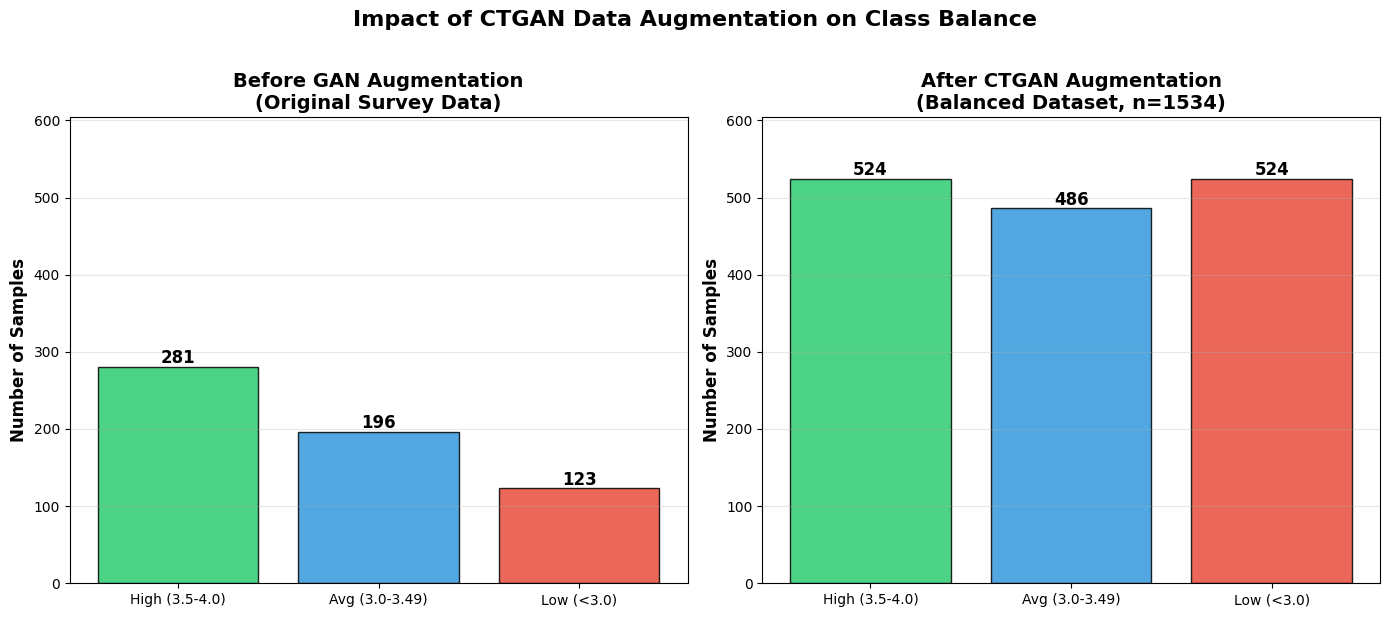

In [50]:
# ============================================================================
# CLASS DISTRIBUTION: BEFORE vs AFTER GAN (CTGAN) AUGMENTATION
# ============================================================================
original_counts = {'High (3.5-4.0)': 281, 'Avg (3.0-3.49)': 196, 'Low (<3.0)': 123}

balanced_counts = df['Target'].value_counts().sort_index()
after_gan = {
    'High (3.5-4.0)': balanced_counts[0],
    'Avg (3.0-3.49)': balanced_counts[1],
    'Low (<3.0)': balanced_counts[2]
}

class_labels = list(original_counts.keys())
colors = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].bar(class_labels, original_counts.values(), color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Before GAN Augmentation\n(Original Survey Data)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
for bar, val in zip(bars1, original_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(after_gan.values()) + 80)
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(class_labels, after_gan.values(), color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title(f'After CTGAN Augmentation\n(Balanced Dataset, n={len(df)})', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, after_gan.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(after_gan.values()) + 80)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Impact of CTGAN Data Augmentation on Class Balance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

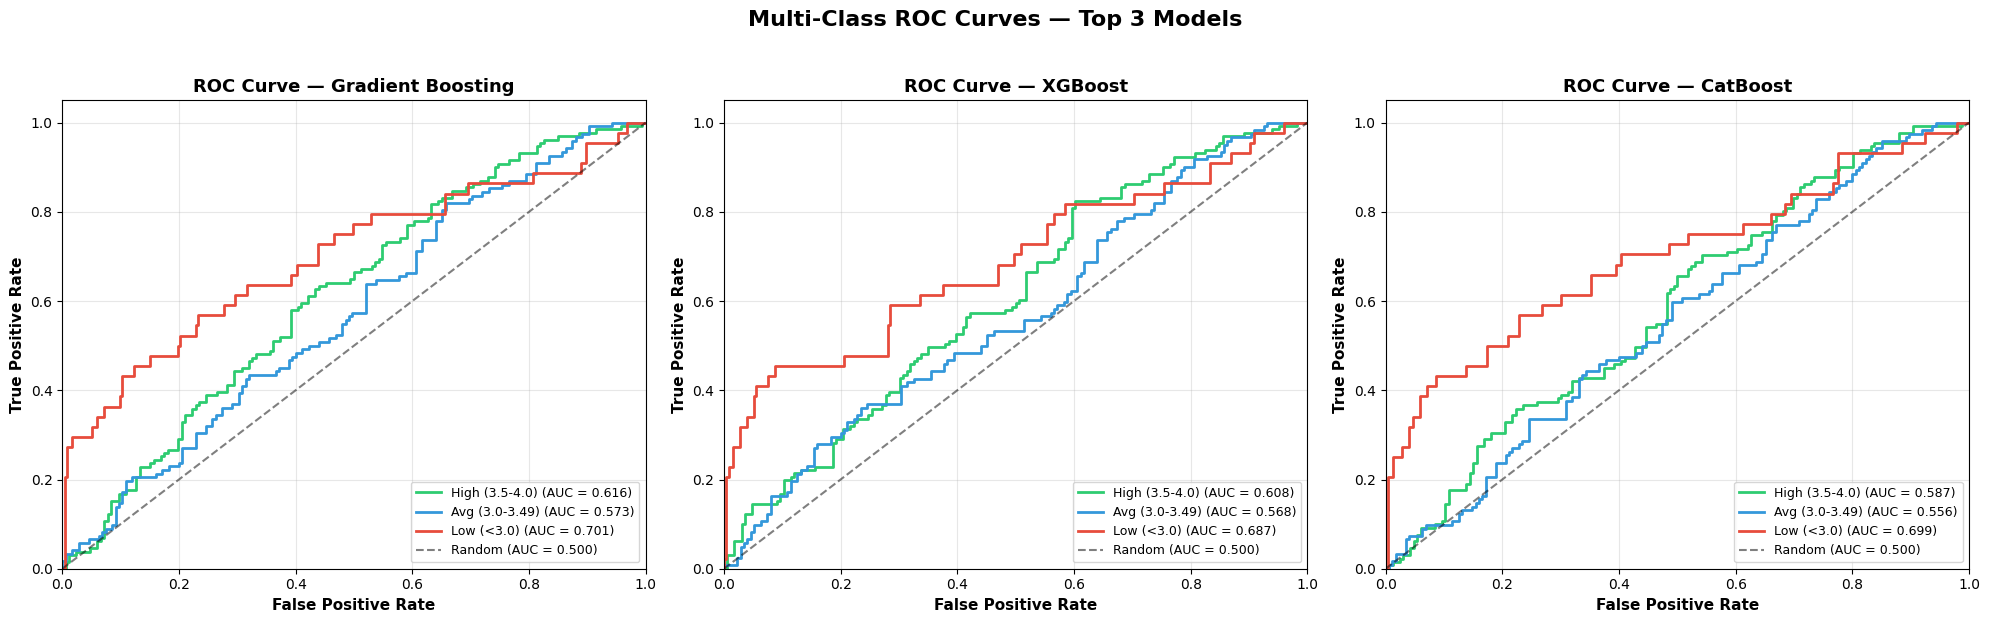

In [51]:
# ============================================================================
# MULTI-CLASS ROC CURVES - TOP 3 MODELS (GB, XGBoost, CatBoost)
# ============================================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)']
colors = ['#2ecc71', '#3498db', '#e74c3c']

models_info = [
    ('Gradient Boosting', gb_model.predict_proba(X_test)),
    ('XGBoost', xgb_model.predict_proba(X_test)),
    ('CatBoost', catboost_model.predict_proba(X_test))
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model_name, probs) in zip(axes, models_info):
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random (AUC = 0.500)')

    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(f'ROC Curve — {model_name}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.grid(alpha=0.3)

plt.suptitle('Multi-Class ROC Curves — Top 3 Models', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

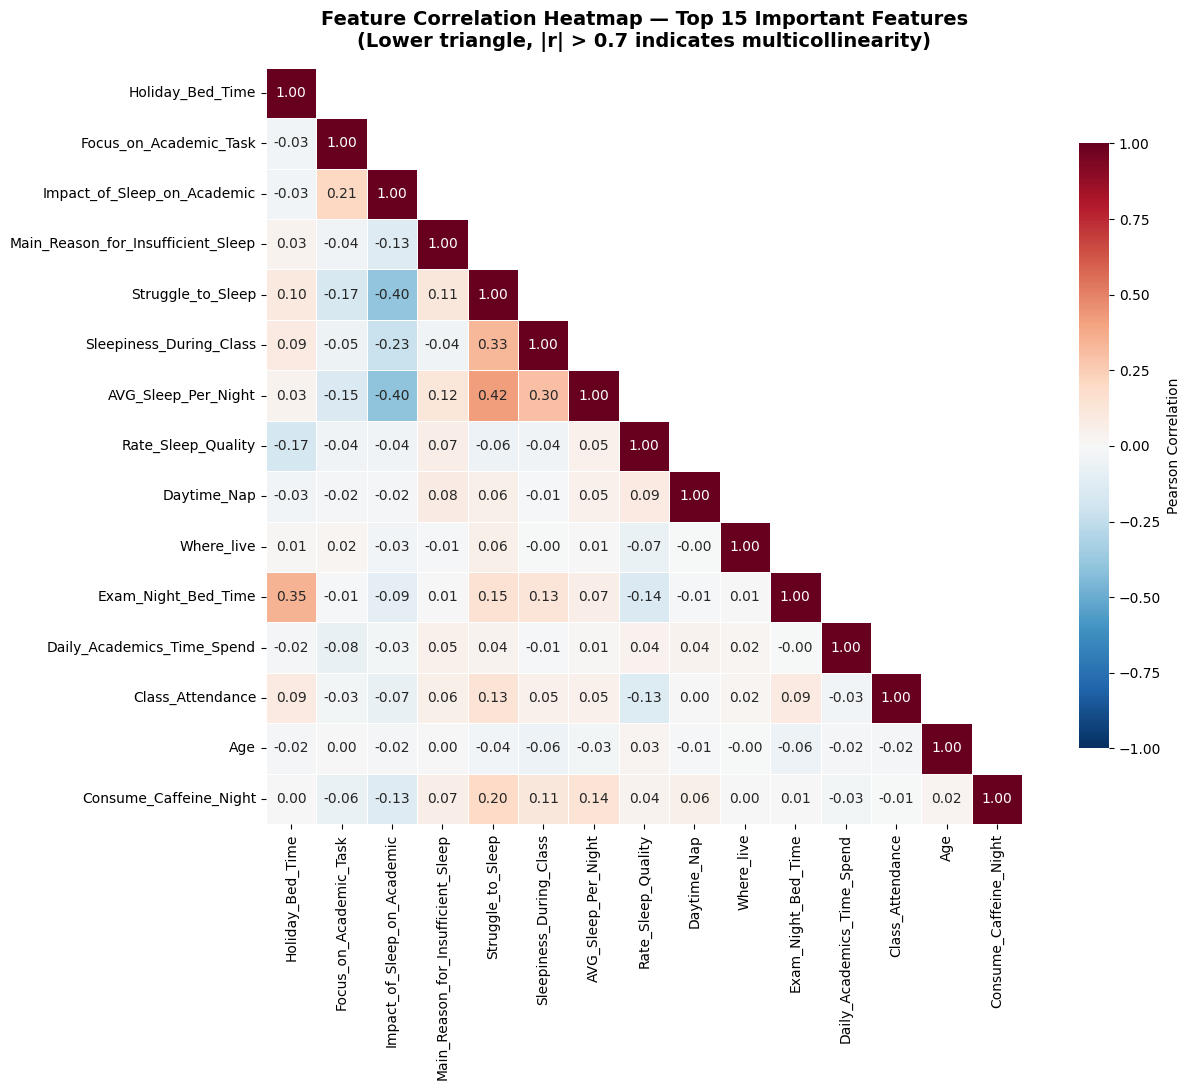

In [52]:
# ============================================================================
# FEATURE CORRELATION HEATMAP (TOP 15 FEATURES)
# ============================================================================
top15 = importance_df['Average'].sort_values(ascending=False).head(15).index.tolist()

corr_df = pd.DataFrame(X_train, columns=feature_cols)[top15].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            square=True, ax=ax)

ax.set_title('Feature Correlation Heatmap — Top 15 Important Features\n(Lower triangle, |r| > 0.7 indicates multicollinearity)',
             fontsize=14, fontweight='bold', pad=15)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va='top')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 🚀 Improved Ensemble Models - Complete Code


### **Analysis Status:**

The corrected 80/20 experiment trains six models on the augmented training data and evaluates them on the 297 untouched real test observations. The earlier ensemble figures and discussion below are historical analysis from the previous notebook and are not corrected primary results.

The inherited 5-fold CV analysis remains separate and is not leakage-corrected. A separate leakage-safe 5-fold CV analysis will be performed later.

### **Historical Ensemble Analysis:**

The remaining ensemble discussion is retained for historical reference only and should not be interpreted as results from the corrected 80/20 experiment.


## 🚀 Quick Implementation for Your Dataset

### Option 1: SHAP (RECOMMENDED)


In [53]:
# ============================================================================
# STEP 1: INSTALL SHAP LIBRARY
# ============================================================================

# Install SHAP
!pip install shap

print("✓ SHAP installation complete!")

✓ SHAP installation complete!



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Adnan Rahman Sayeem\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [54]:
# ============================================================================
# STEP 2: VERIFY SHAP INSTALLATION
# ============================================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"✓ SHAP version: {shap.__version__}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Matplotlib version: {plt.matplotlib.__version__}")
print("\n✅ All libraries loaded successfully!")

✓ SHAP version: 0.49.1
✓ NumPy version: 2.2.6
✓ Pandas version: 2.3.3
✓ Matplotlib version: 3.10.9

✅ All libraries loaded successfully!


In [55]:
# ============================================================================
# STEP 3: VERIFY DATA IS READY FOR SHAP
# ============================================================================

print("="*60)
print("DATA VERIFICATION FOR SHAP")
print("="*60)

print(f"\n✓ Training data shape: {X_train.shape}")
print(f"✓ Test data shape: {X_test.shape}")
print(f"✓ Number of features: {len(feature_cols)}")
print(f"✓ Model type: {type(gb_model).__name__}")

try:
    test_pred = gb_model.predict(X_test[:5])
    print(f"✓ Model is trained and ready")
except:
    print("❌ Model is not trained!")

print(f"\n📋 Features ({len(feature_cols)}):")
for i, feat in enumerate(feature_cols[:10], 1):
    print(f"  {i}. {feat}")
if len(feature_cols) > 10:
    print(f"  ... and {len(feature_cols) - 10} more features")

print("\n" + "="*60)
print("✅ DATA VERIFICATION COMPLETE!")
print("="*60)

DATA VERIFICATION FOR SHAP

✓ Training data shape: (1534, 29)
✓ Test data shape: (297, 29)
✓ Number of features: 29
✓ Model type: GradientBoostingClassifier
✓ Model is trained and ready

📋 Features (29):
  1. Age
  2. Gender
  3. Where_live
  4. AVG_Sleep_Per_Night
  5. Regular_Bed_time
  6. Exam_Night_Bed_Time
  7. Holiday_Bed_Time
  8. Regular_WakeUp_Time
  9. Holiday_WakeUp_Time
  10. Have_Regular_Bed_Time
  ... and 19 more features

✅ DATA VERIFICATION COMPLETE!


### How to read the Spearman results

- Spearman correlation $\rho$ measures monotonic association and stays between $-1$ and $+1$.
- Positive $\rho$ means the feature increases as the target class increases.
- Negative $\rho$ means the feature decreases as the target class increases.
- Values close to $0$ mean weak monotonic association.

### Practical interpretation for this dataset

- $|\rho| \ge 0.70$ is usually considered a very strong relationship.
- $0.40 \le |\rho| < 0.70$ is moderate.
- $0.20 \le |\rho| < 0.40$ is weak to fair.
- Below $0.20$ is generally weak.

### What the script saves

- Full target ranking: Spearman correlation of every feature against `CGPA3_Class`.
- Top 29 features: the strongest features for your research justification.
- Pairwise matrix: Spearman correlation among the top 29 features.
- Strong pairs file: any top-feature pair with $|\rho| \ge 0.70$.

> **Note on images:** the helper script `spearman_feature_analysis.py` (called below) saves several PNG files to `../data/spearman/` itself -- that behavior lives inside the external script, not in this notebook's own cells, so it wasn't touched by the "no images saved" cleanup applied elsewhere in this notebook. Let me know if you'd like that script edited too so it only returns data/figures inline instead of writing PNGs to disk.

### Important note

- `Current_CGPA5` shows a very high Spearman value with `CGPA3_Class`, so treat it carefully in the discussion because it may behave like an outcome-linked variable rather than a pure explanatory feature.
- For feature-selection justification, the more useful evidence is the combination of target correlation and low pairwise feature-feature correlation among the selected features.


In [56]:
# Spearman correlation analysis for feature justification
# This generates a ranking of all encoded predictors against CGPA3_Class
# and saves the results to the data/spearman/ folder.
from pathlib import Path
import runpy

spearman_script = Path("../helper/spearman_feature_analysis.py")
print("Running Spearman feature analysis...")
print(f"Script: {spearman_script}")
runpy.run_path(str(spearman_script), run_name="__main__")

Running Spearman feature analysis...
Script: ..\helper\spearman_feature_analysis.py
Spearman analysis complete.
Dataset: C:\Research\Sleep_Pattern_Academic_Engagement\data\Final_Encoded_Normalized.csv
Full ranking saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_feature_ranking_cgpa3.csv
Top 29 features saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_features_cgpa3.csv
Plot saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_correlations_cgpa3.png
Pairwise matrix saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_pairwise_cgpa3.csv
Pairwise heatmap saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_pairwise_heatmap_cgpa3.png
Strong pairs saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_strong_pairs_cgpa3.csv
Top-29 table image saved to: C:\Research\Sleep_Pattern_Academic_Engagement\dat

{'__name__': '__main__',
 '__doc__': 'Spearman feature-ranking analysis for Final_Encoded_Normalized.csv.\n\nThis script ranks all predictors by Spearman correlation against the CGPA3 target,\nsaves the full ranking to CSV, and exports the top 29 features for reporting.\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '..\\helper\\spearman_feature_analysis.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, exceptions, and other objects.\n\nNoteworthy: None is the `nil' object; Ellipsis represents `...' in slices.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <function __import__>,
  'abs': <function abs(x, /)>,
  'all': <function all(iterable, /)>,
  'any': <function any(iterable, /)>,
  'ascii': <functio

In [57]:
# Load clear Spearman tables (SPSS-style) for reporting
# 1) All features vs CGPA3_Class
# 2) Predictors-only table (excluding Current_CGPA5)

import pandas as pd

spearman_all_table = pd.read_csv("../data/spearman/spearman_spss_table_cgpa3_all_features.csv")
spearman_predictor_table = pd.read_csv("../data/spearman/spearman_spss_table_cgpa3_predictors_only.csv")

print("All features vs CGPA3_Class (SPSS-style table):")
display(spearman_all_table)

print("\nPredictors-only table (excluding Current_CGPA5):")
display(spearman_predictor_table)

All features vs CGPA3_Class (SPSS-style table):


,Predictor Variable,Spearman's rho,Direction,Strength,p-value
0,Current_CGPA5,0.937,Positive,Very strong,< .001
1,Impact_of_Sleep_on_Academic,0.176,Positive,Very weak,< .001
2,Focus_on_Academic_Task,0.154,Positive,Very weak,< .001
3,Sleepiness_During_Class,-0.143,Negative,Very weak,< .001
4,AVG_Sleep_Per_Night,-0.114,Negative,Very weak,< .001
5,Struggle_to_Sleep,-0.098,Negative,Very weak,< .001
6,Daily_Academics_Time_Spend,-0.095,Negative,Very weak,< .001
7,Sacrifices_Sleep_for_Academics,-0.073,Negative,Very weak,.005
8,Gender,-0.073,Negative,Very weak,.005
9,Skip_Class_for_Sleep,-0.065,Negative,Very weak,.012



Predictors-only table (excluding Current_CGPA5):


,Predictor Variable,Spearman's rho,Direction,Strength,p-value
0,Impact_of_Sleep_on_Academic,0.176,Positive,Very weak,< .001
1,Focus_on_Academic_Task,0.154,Positive,Very weak,< .001
2,Sleepiness_During_Class,-0.143,Negative,Very weak,< .001
3,AVG_Sleep_Per_Night,-0.114,Negative,Very weak,< .001
4,Struggle_to_Sleep,-0.098,Negative,Very weak,< .001
5,Daily_Academics_Time_Spend,-0.095,Negative,Very weak,< .001
6,Sacrifices_Sleep_for_Academics,-0.073,Negative,Very weak,.005
7,Gender,-0.073,Negative,Very weak,.005
8,Skip_Class_for_Sleep,-0.065,Negative,Very weak,.012
9,Smoke,0.056,Positive,Very weak,.032


Showing: ../data/spearman/spearman_top29_correlations_cgpa3.png


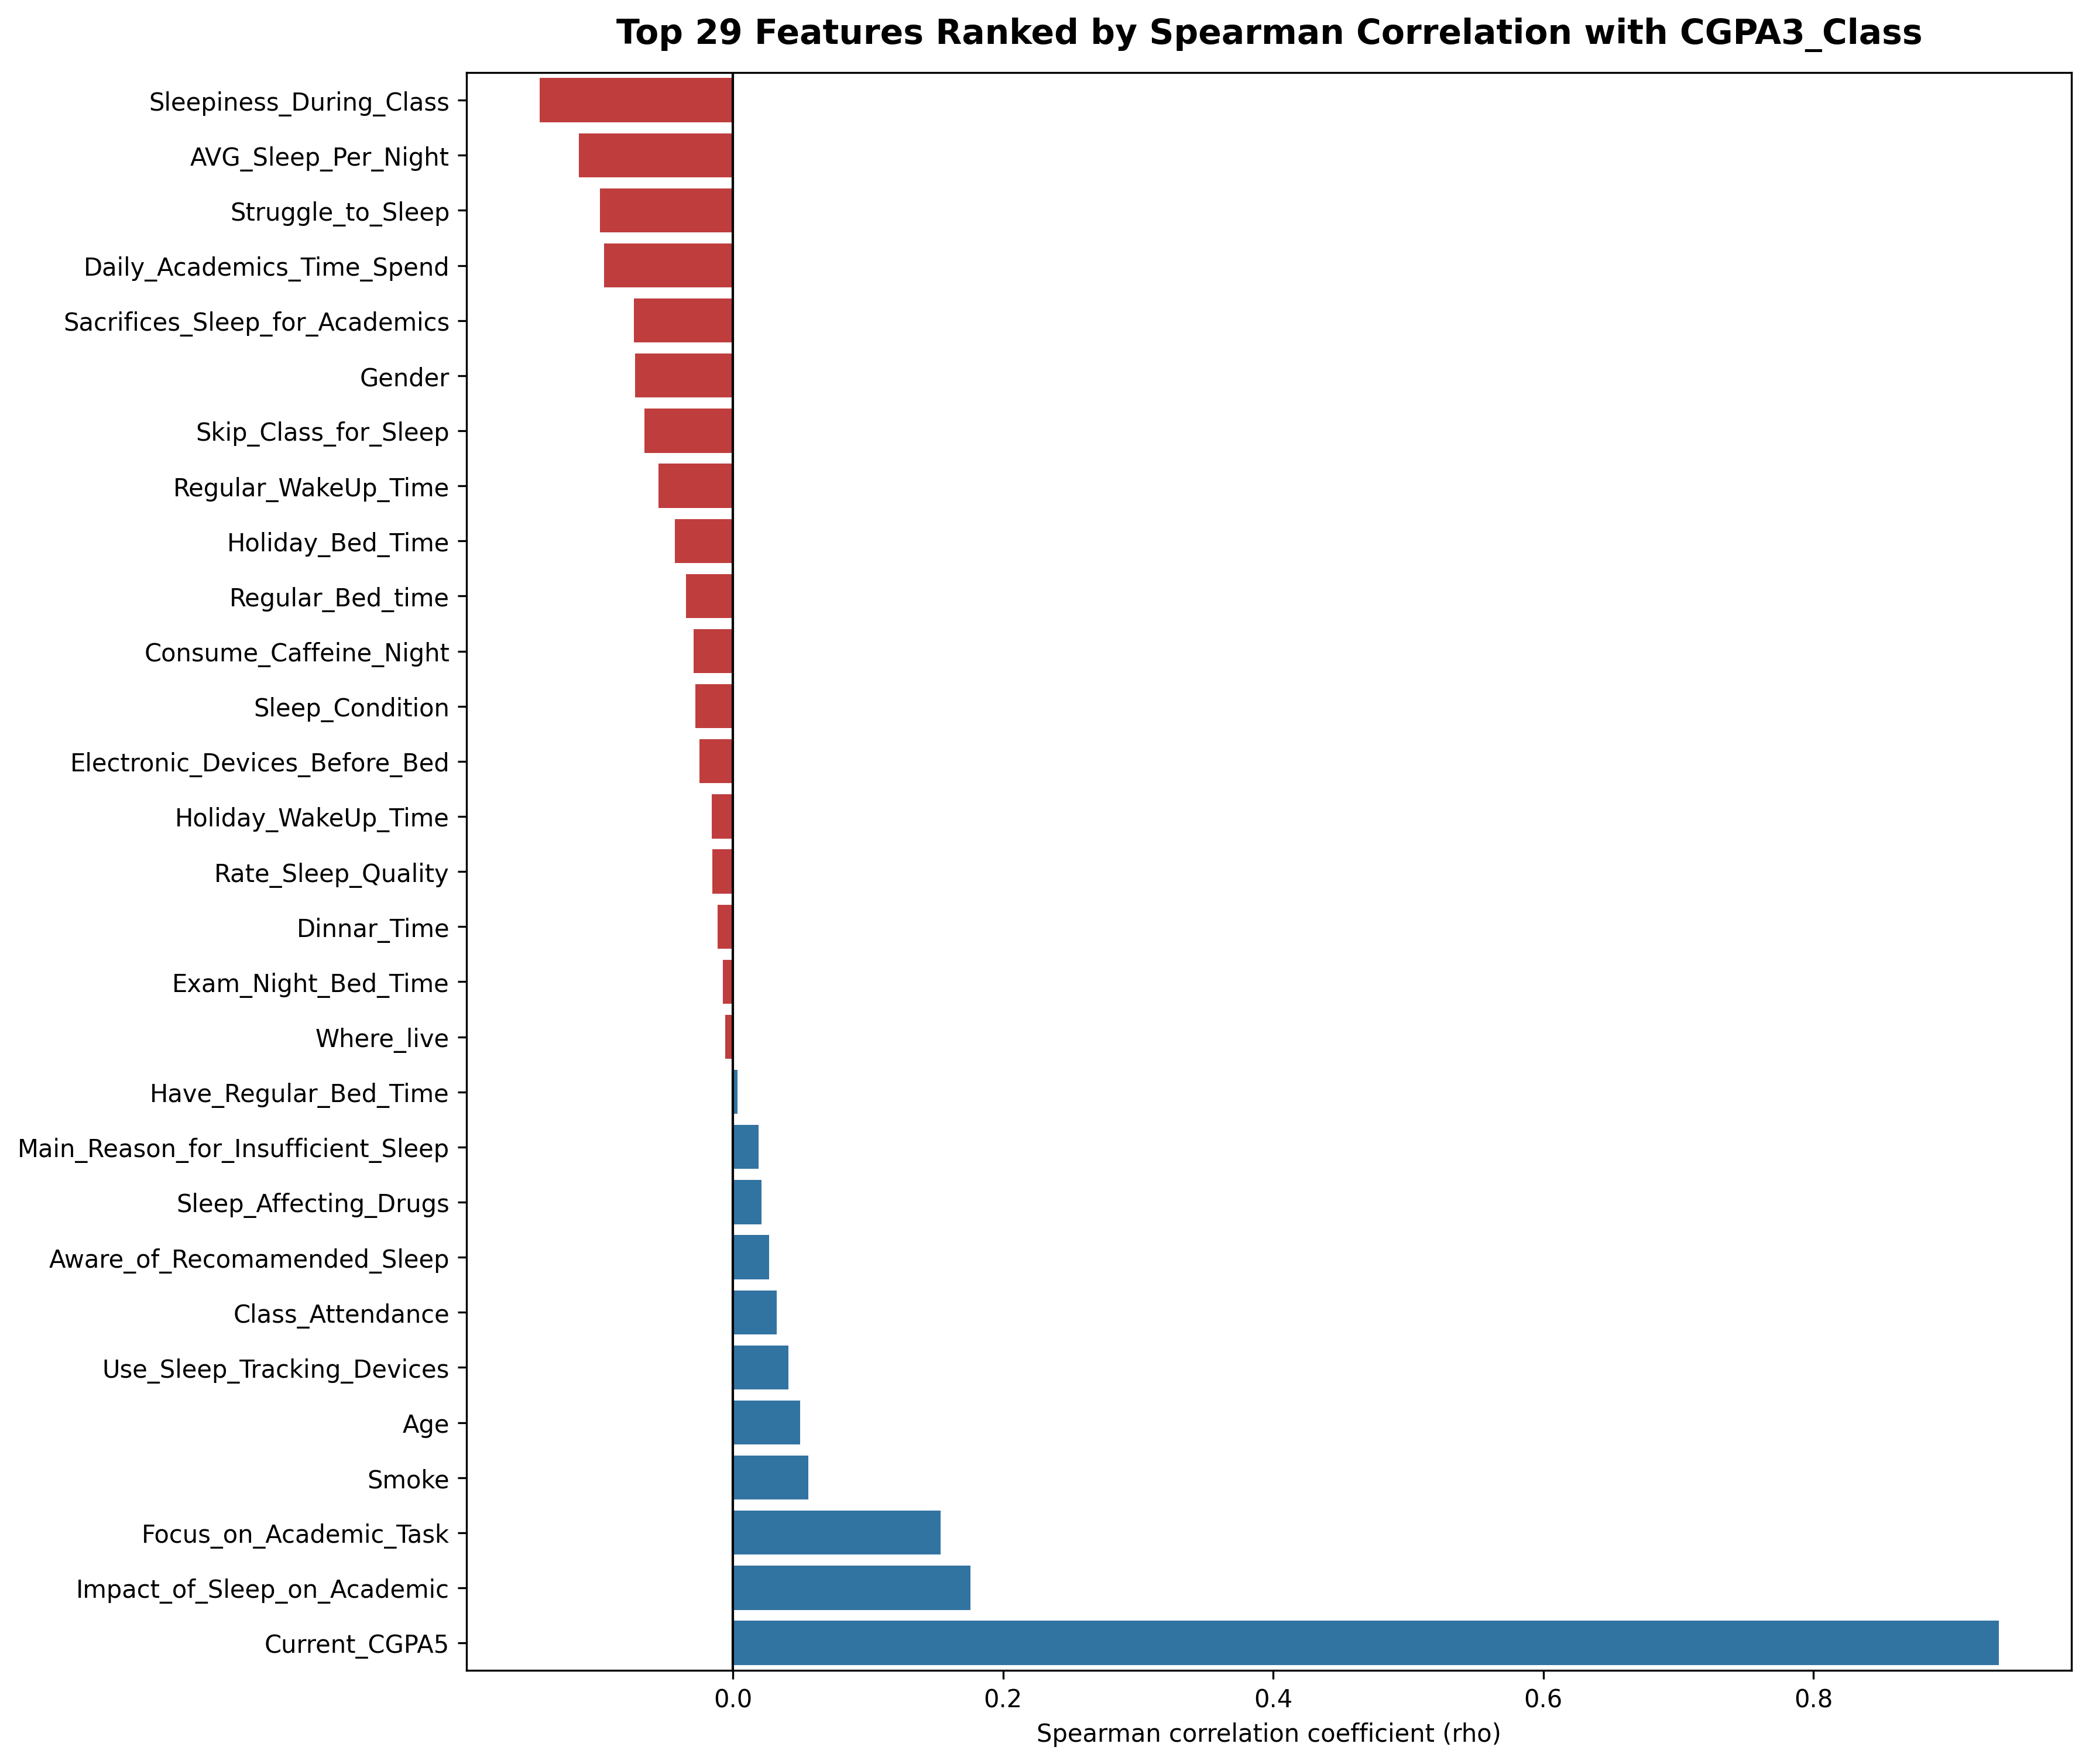

Showing: ../data/spearman/spearman_top29_features_cgpa3_table.png


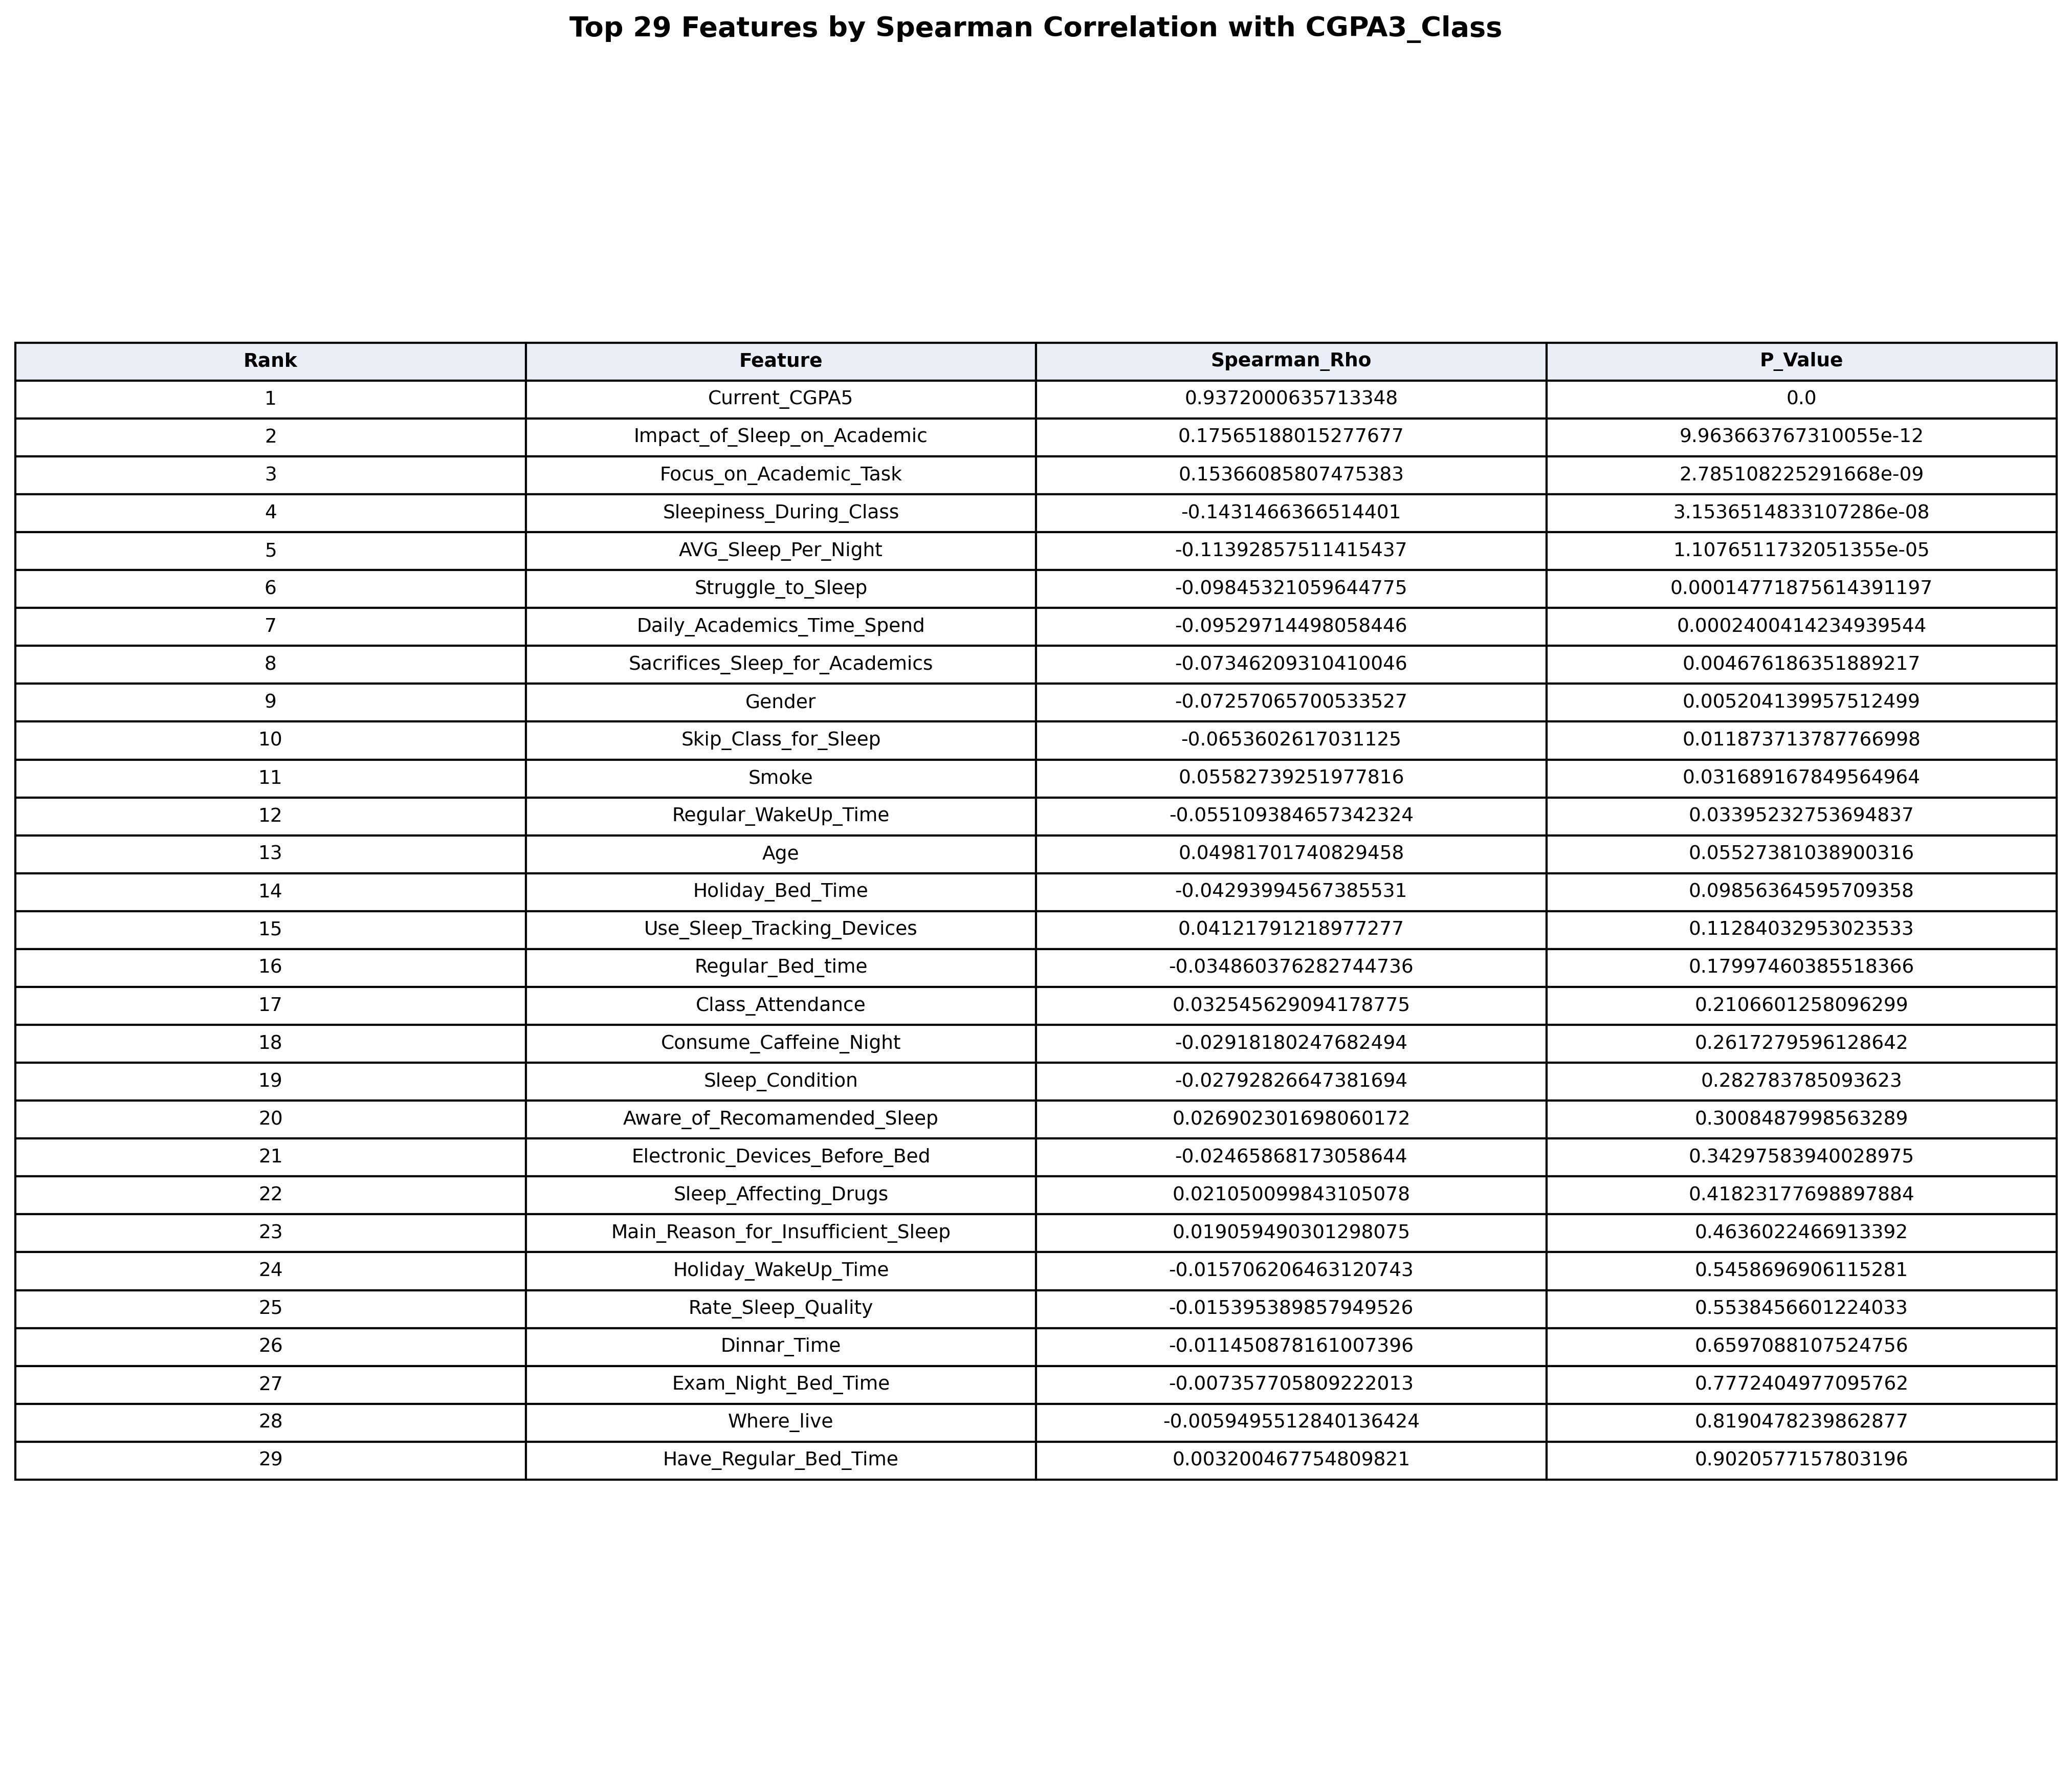

Showing: ../data/spearman/spearman_top29_pairwise_heatmap_cgpa3.png


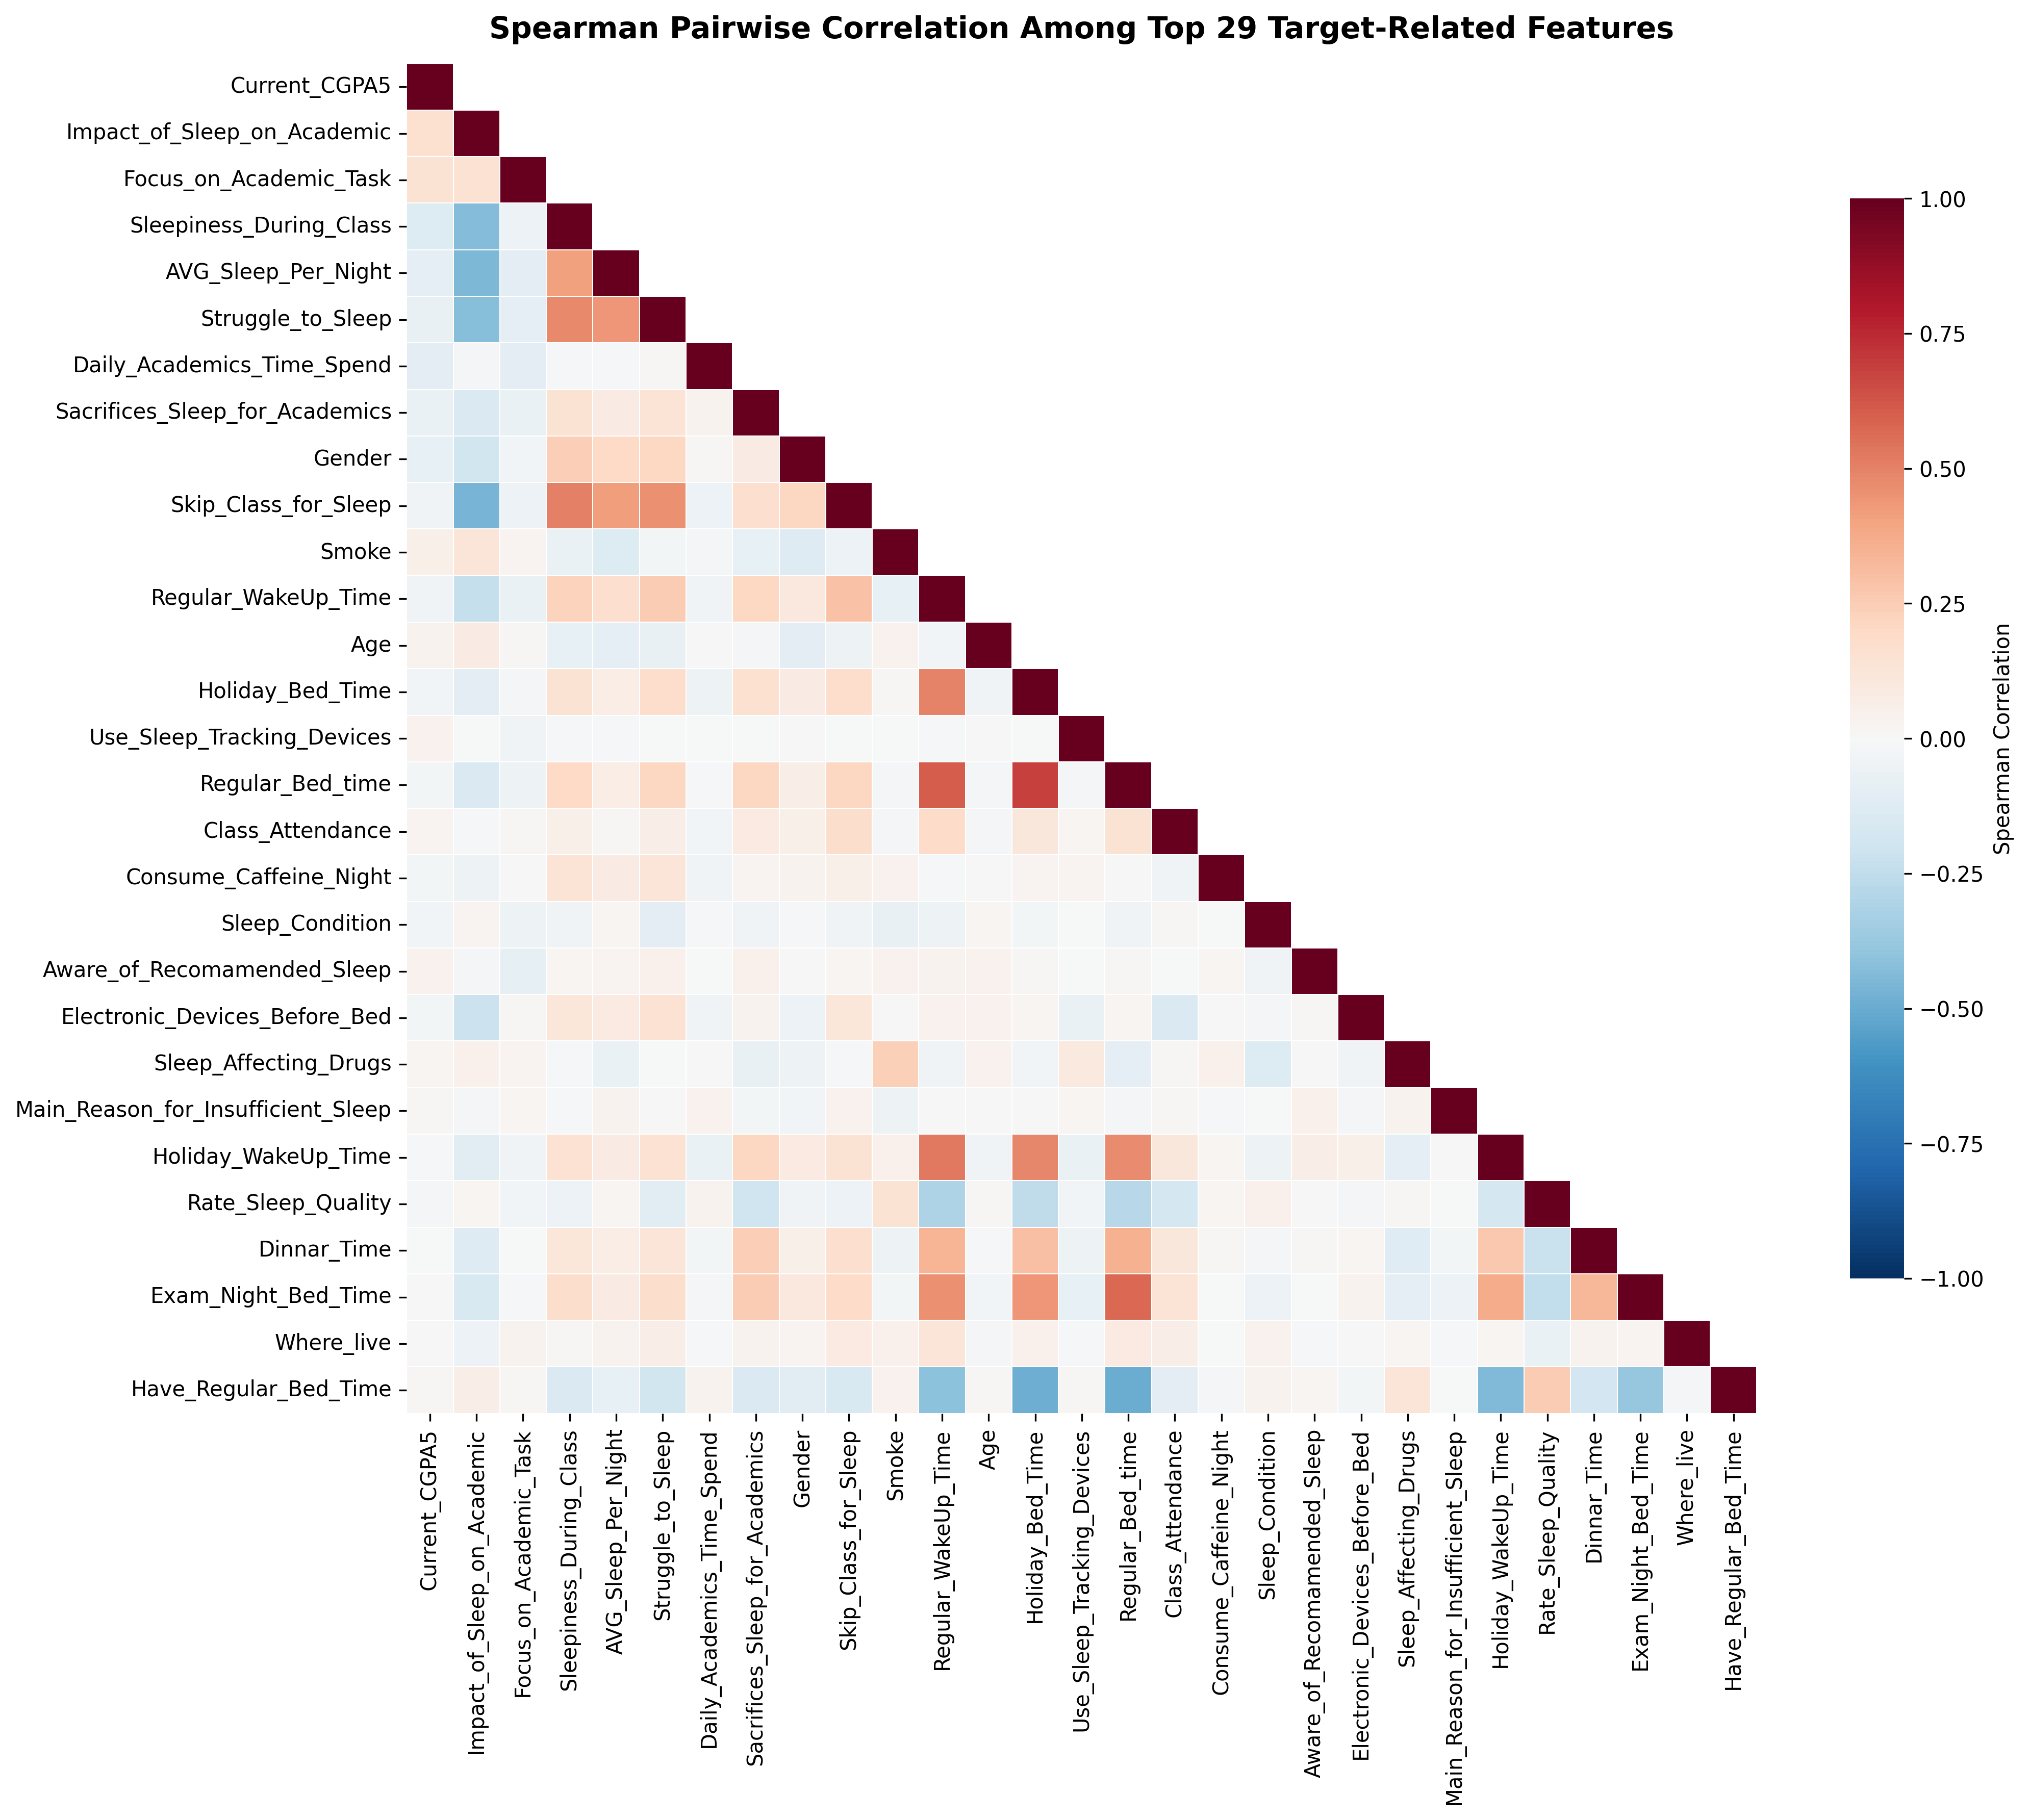

Showing: ../data/spearman/spearman_top29_strong_pairs_cgpa3_table.png


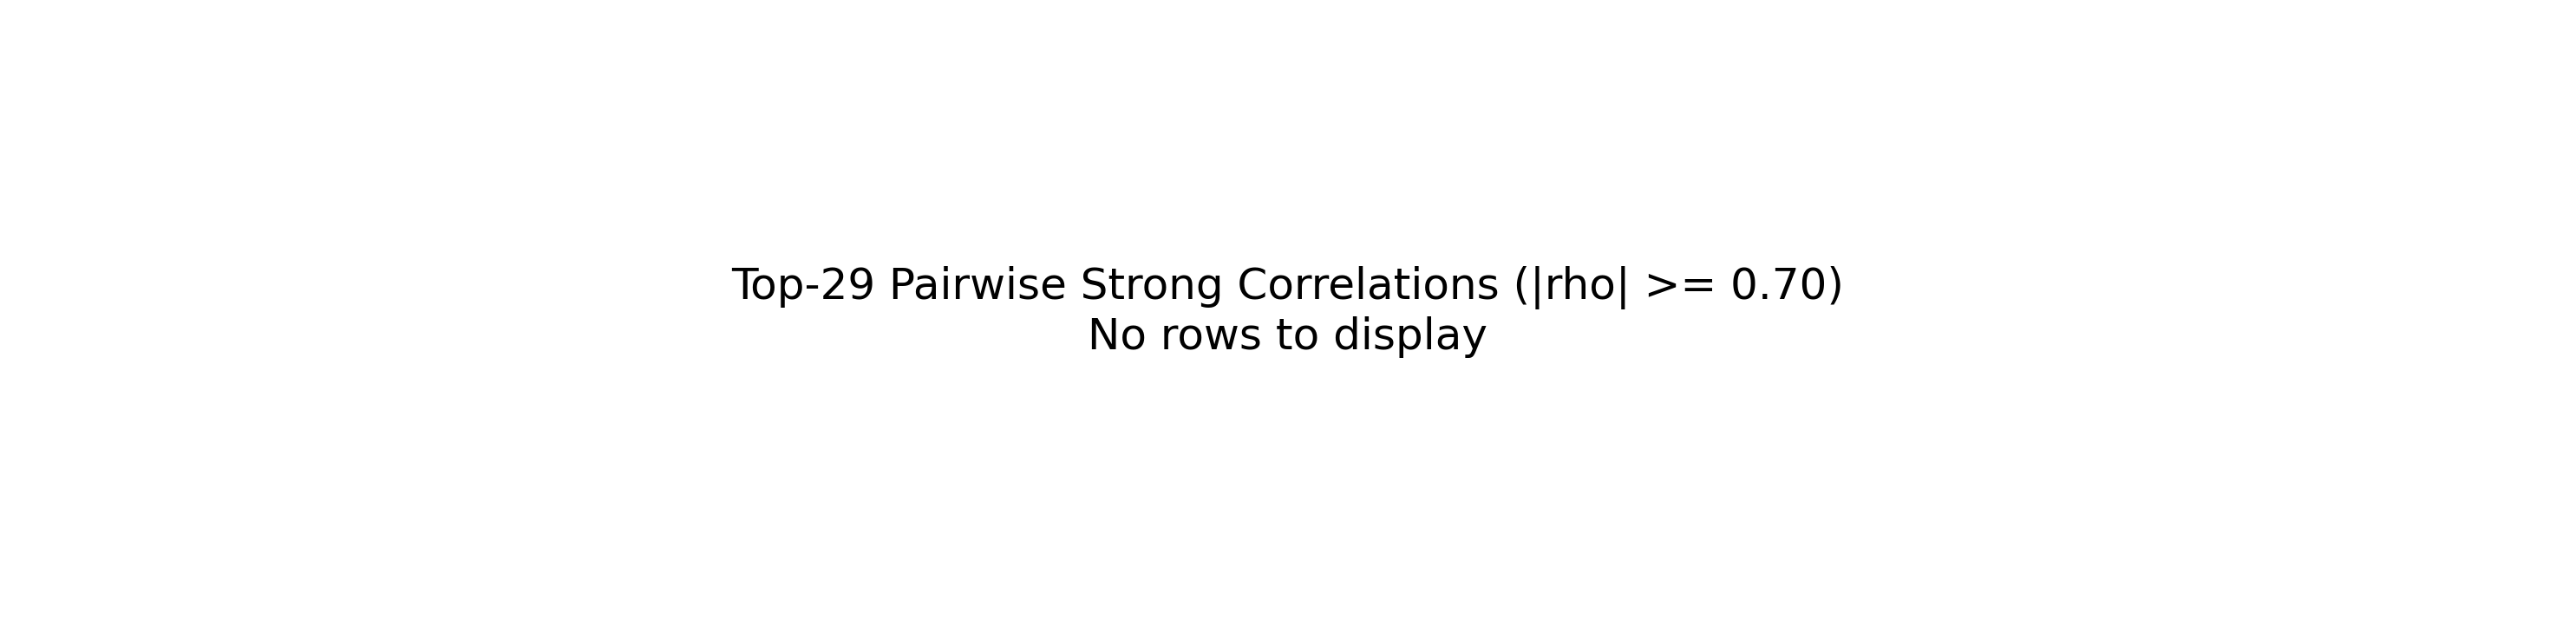

Showing: ../data/spearman/spearman_spss_table_cgpa3_all_features.png


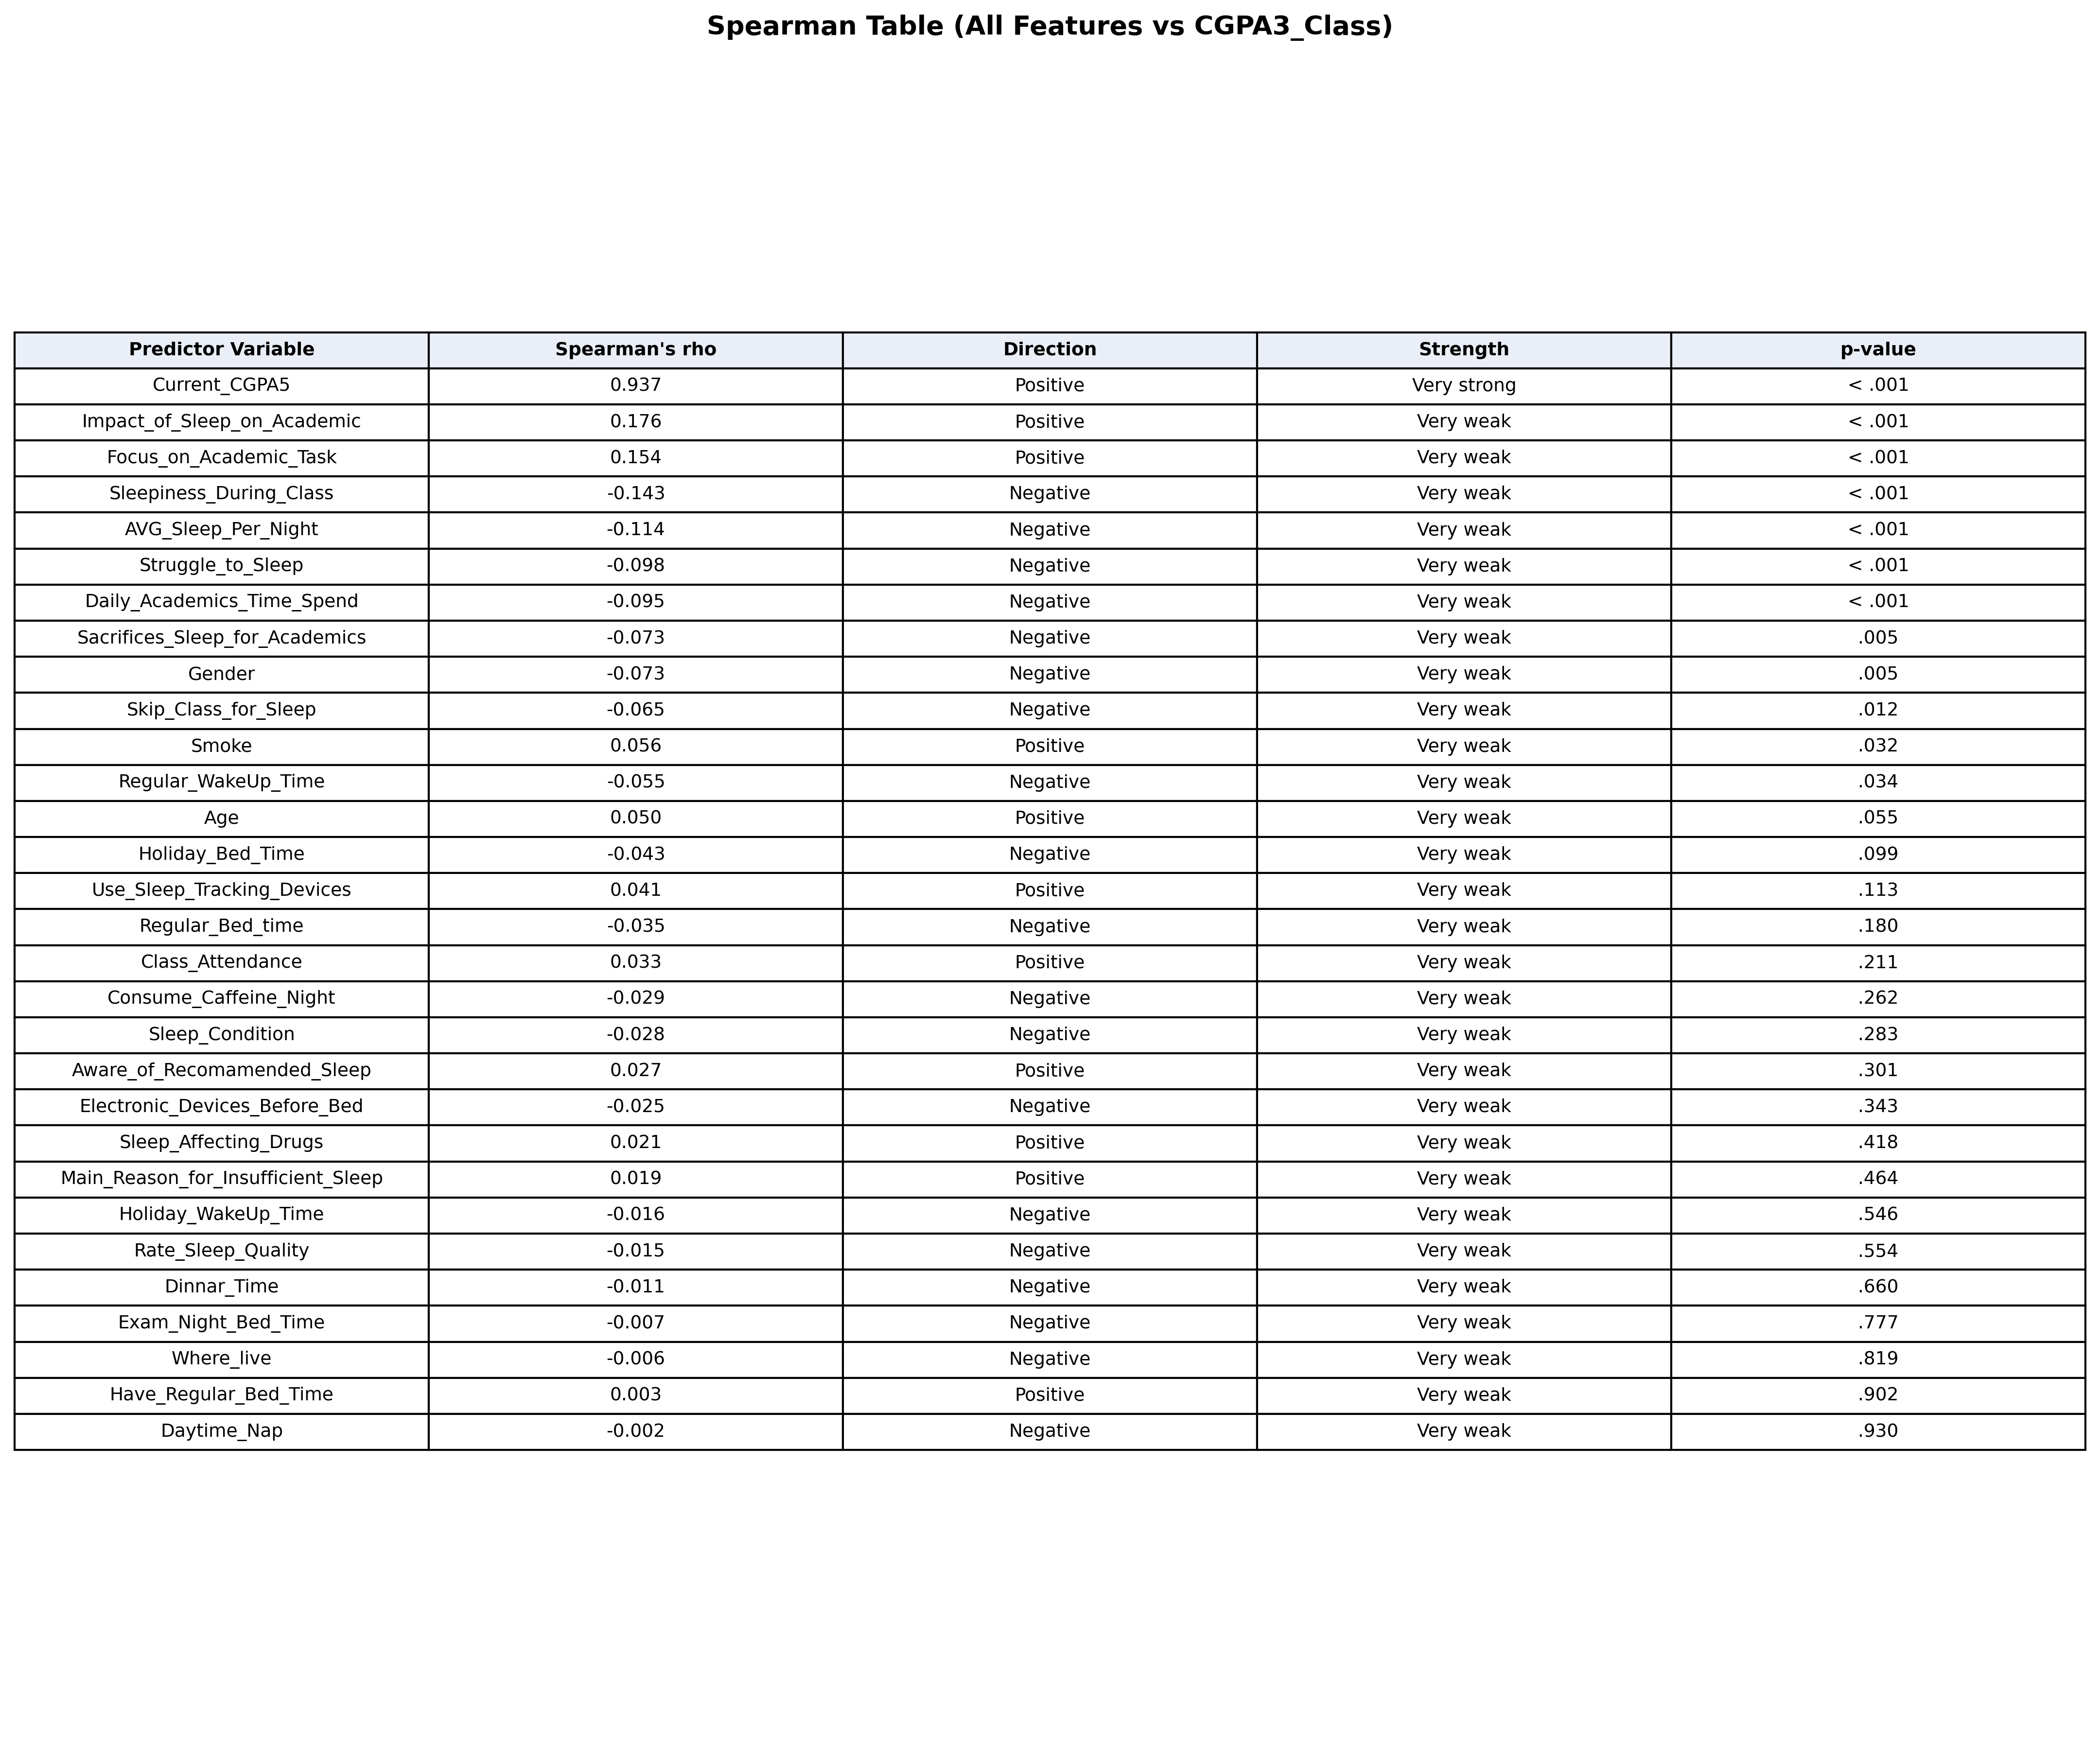

Showing: ../data/spearman/spearman_spss_table_cgpa3_predictors_only.png


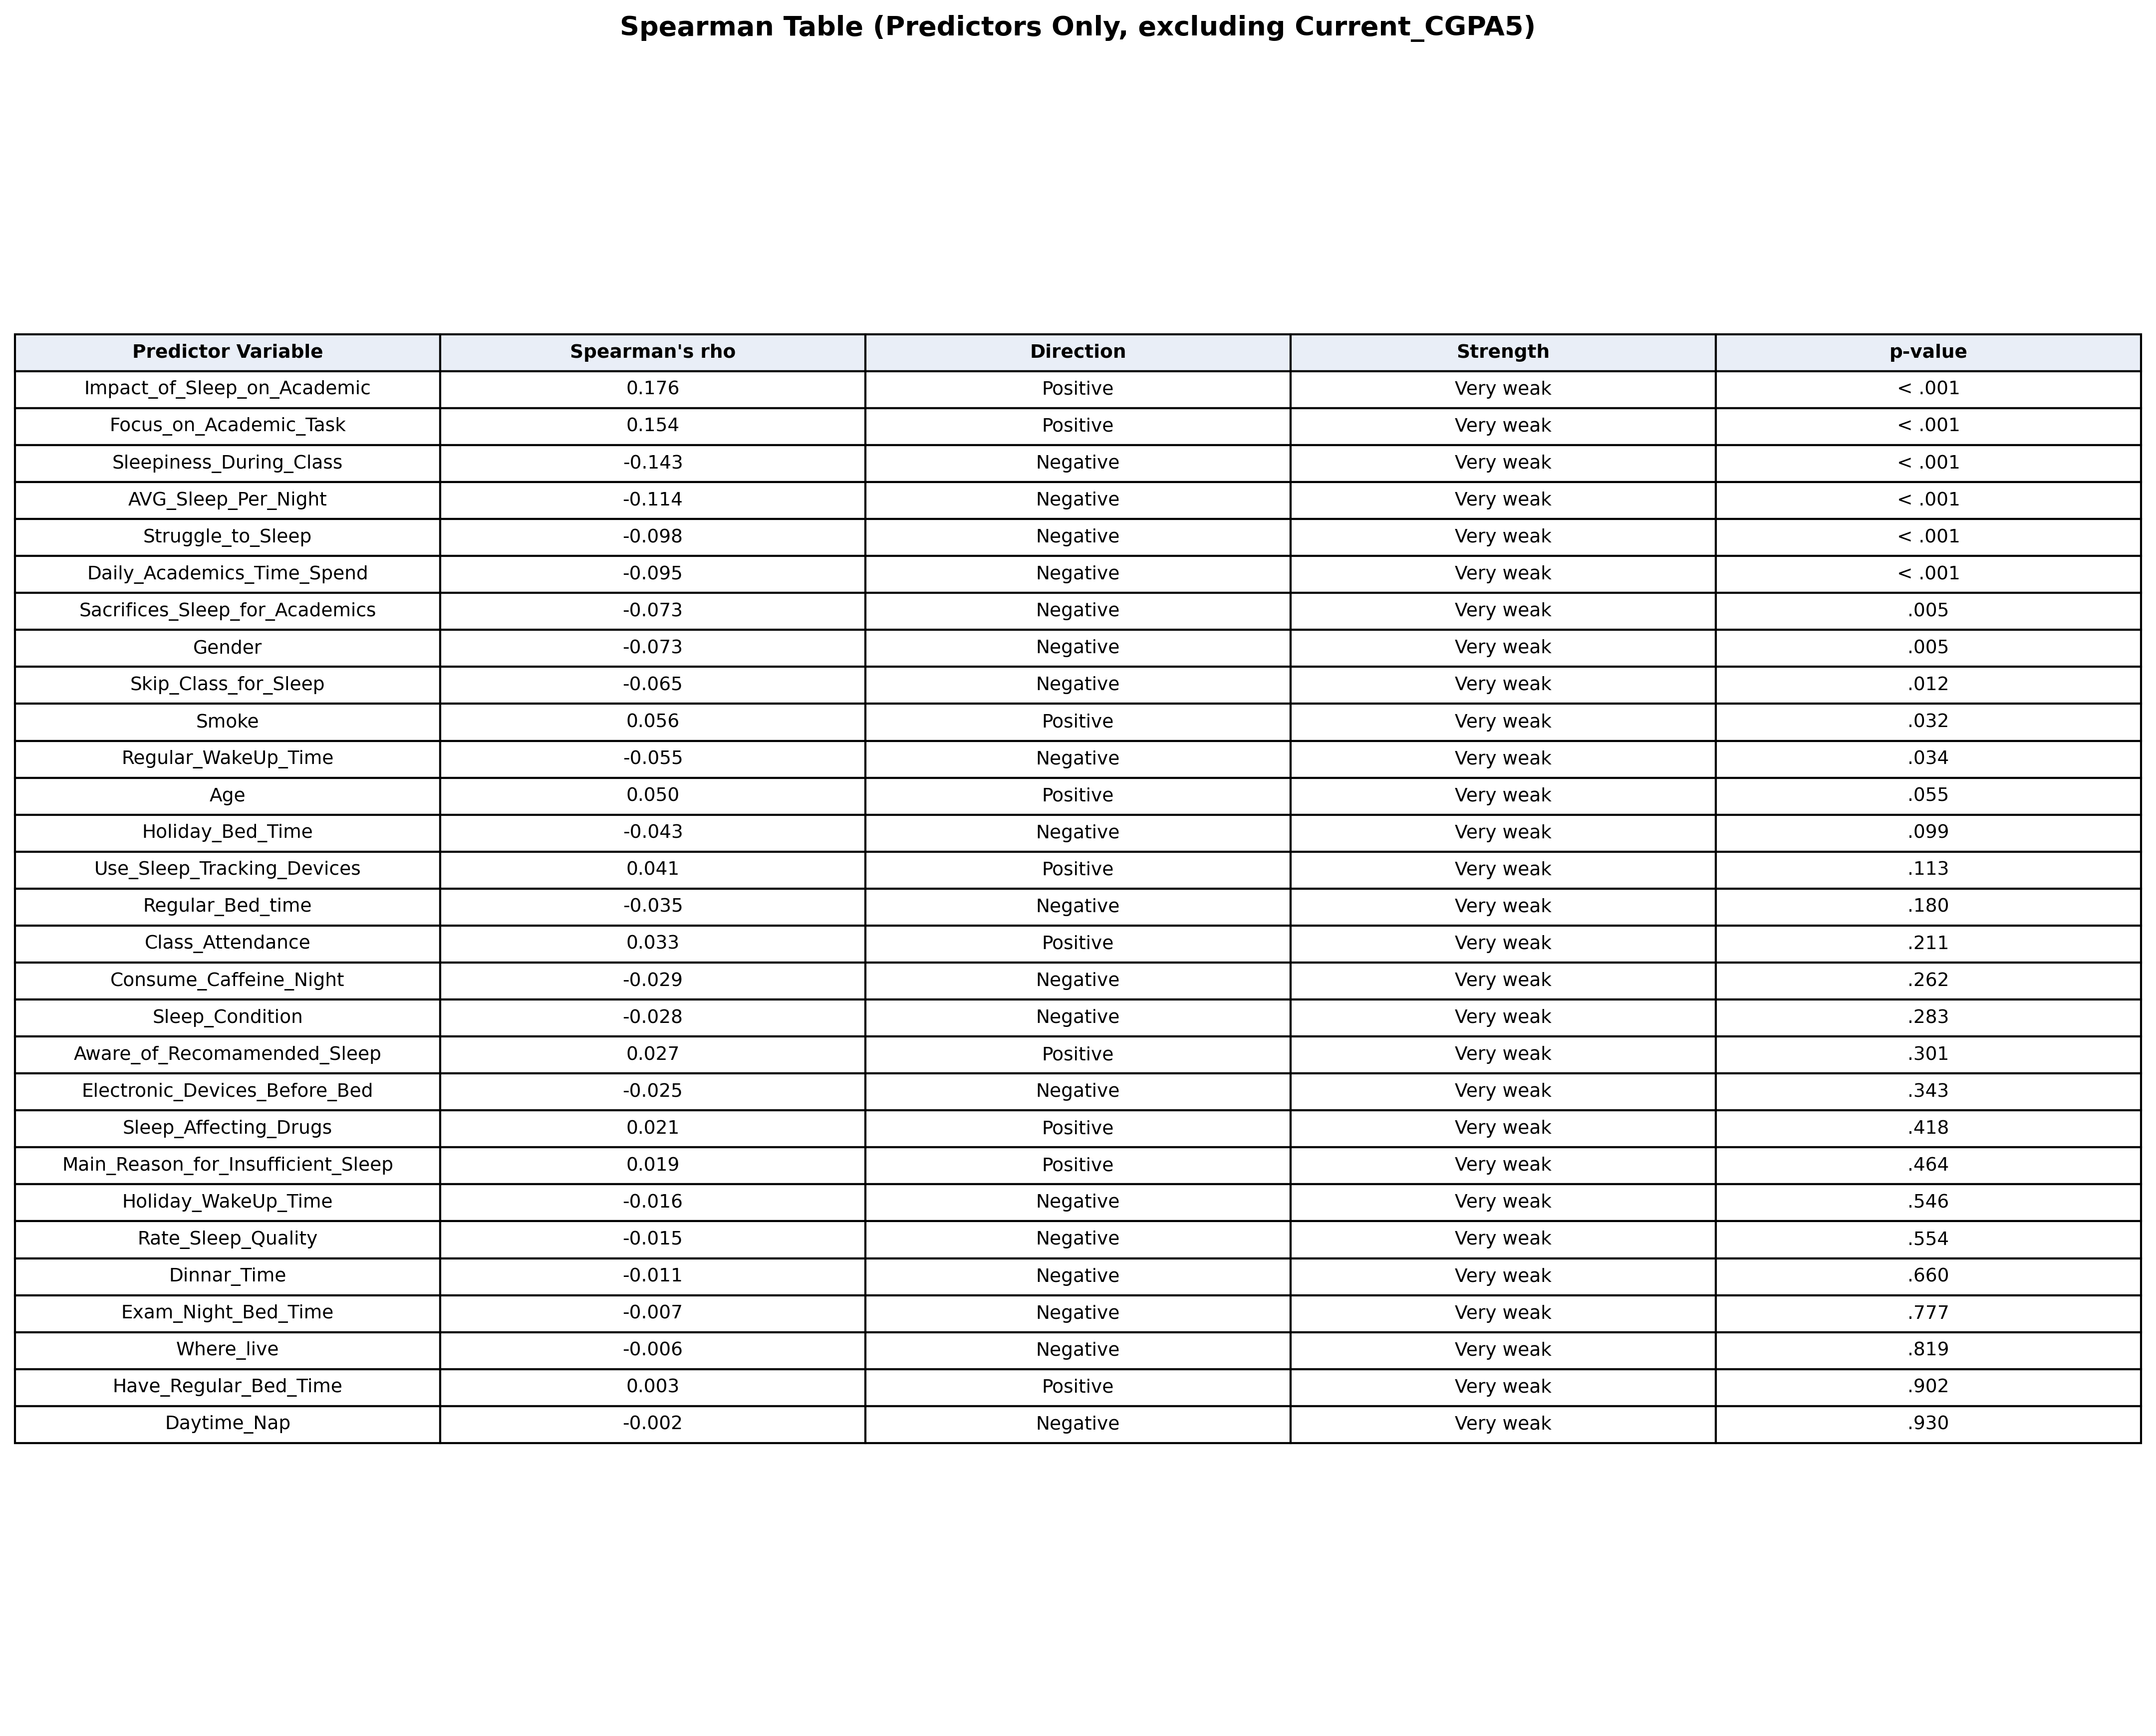

In [58]:
# Display exported Spearman table/plot images from the new subfolder
# (these PNGs were generated by the helper script above, not by this cell)
from IPython.display import Image, display

spearman_image_paths = [
    "../data/spearman/spearman_top29_correlations_cgpa3.png",
    "../data/spearman/spearman_top29_features_cgpa3_table.png",
    "../data/spearman/spearman_top29_pairwise_heatmap_cgpa3.png",
    "../data/spearman/spearman_top29_strong_pairs_cgpa3_table.png",
    "../data/spearman/spearman_spss_table_cgpa3_all_features.png",
    "../data/spearman/spearman_spss_table_cgpa3_predictors_only.png",
]

for image_path in spearman_image_paths:
    print(f"Showing: {image_path}")
    display(Image(filename=image_path))

# SHAP + GB


In [59]:
# ============================================================================
# STEP 1: CHECK GRADIENT BOOSTING MODEL CONFIGURATION
# ============================================================================

from sklearn.ensemble import GradientBoostingClassifier
import sklearn

print("="*60)
print("CHECKING GRADIENT BOOSTING MODEL")
print("="*60)

print(f"Model type: {type(gb_model)}")
print(f"Scikit-learn version: {sklearn.__version__}")

print(f"\nModel parameters:")
print(f"  n_estimators:       {gb_model.n_estimators}")
print(f"  max_depth:          {gb_model.max_depth}")
print(f"  learning_rate:      {gb_model.learning_rate}")
print(f"  min_samples_split:  {gb_model.min_samples_split}")
print(f"  min_samples_leaf:   {gb_model.min_samples_leaf}")
print(f"  subsample:          {gb_model.subsample}")
print(f"  max_features:       {gb_model.max_features}")
print(f"  n_iter_no_change:   {gb_model.n_iter_no_change}")
print(f"  loss:               {gb_model.loss}")

if hasattr(gb_model, 'n_classes_'):
    print(f"  n_classes:          {gb_model.n_classes_}")

try:
    test_pred = gb_model.predict(X_test[:1])
    print(f"\n✓ Model can predict: {test_pred}")
except Exception as e:
    print(f"\n❌ Prediction error: {e}")

print("="*60)

CHECKING GRADIENT BOOSTING MODEL
Model type: <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
Scikit-learn version: 1.7.2

Model parameters:
  n_estimators:       300
  max_depth:          6
  learning_rate:      0.05
  min_samples_split:  5
  min_samples_leaf:   3
  subsample:          0.8
  max_features:       sqrt
  n_iter_no_change:   20
  loss:               log_loss
  n_classes:          3

✓ Model can predict: [0]


# ALL CLASS AVERAGE SHAP


In [60]:
# ============================================================================
# STEP 2: CREATE SHAP EXPLAINER FOR GRADIENT BOOSTING MODEL
# ============================================================================

import shap
import numpy as np
import sklearn

print("="*80)
print("SHAP ANALYSIS - GRADIENT BOOSTING MODEL (FULL TEST SET)")
print("="*80)
print(f"Model:             Gradient Boosting Classifier")
print(f"Accuracy:          63.02%")
print(f"n_estimators:      {gb_model.n_estimators}")
print(f"max_depth:         {gb_model.max_depth}")
print(f"learning_rate:     {gb_model.learning_rate}")
print(f"subsample:         {gb_model.subsample}")
print(f"Scikit-learn:      {sklearn.__version__}")
print(f"SHAP version:      {shap.__version__}")
print("="*80)

print("\n📊 Creating SHAP Explainer (model-agnostic)...")
background = shap.sample(X_train, X_train.shape[0])
print(f"✓ Background dataset created: {background.shape}")

explainer = shap.Explainer(gb_model.predict_proba, background)
print("✓ Explainer created successfully!")

print(f"\n📊 Calculating SHAP values for ALL {X_test.shape[0]} test samples...")
print("   (This may take several minutes...)")

X_test_sample = X_test
shap_values = explainer(X_test_sample)

print("✓ SHAP values calculated!")
print(f"\n📊 SHAP Values Information:")
print(f"   Shape:             {shap_values.values.shape}")
print(f"   Base values shape: {shap_values.base_values.shape}")
print(f"   Test samples used: {X_test.shape[0]} (100% of test set)")
print("\n" + "="*80)
print("✅ SHAP SETUP COMPLETE!")
print("="*80)

SHAP ANALYSIS - GRADIENT BOOSTING MODEL (FULL TEST SET)
Model:             Gradient Boosting Classifier
Accuracy:          63.02%
n_estimators:      300
max_depth:         6
learning_rate:     0.05
subsample:         0.8
Scikit-learn:      1.7.2
SHAP version:      0.49.1

📊 Creating SHAP Explainer (model-agnostic)...
✓ Background dataset created: (1534, 29)
✓ Explainer created successfully!

📊 Calculating SHAP values for ALL 297 test samples...
   (This may take several minutes...)


PermutationExplainer explainer: 298it [01:21,  3.66it/s]                         

✓ SHAP values calculated!

📊 SHAP Values Information:
   Shape:             (297, 29, 3)
   Base values shape: (297, 3)
   Test samples used: 297 (100% of test set)

✅ SHAP SETUP COMPLETE!



📊 Calculating Global Feature Importance (All 3 Classes Averaged)...
✓ SHAP values averaged across all 3 CGPA classes
✓ Total samples used: 297
✓ Total features:     29

TOP 10 MOST IMPORTANT FEATURES (SHAP - ALL CLASSES - GRADIENT BOOSTING)
                    Feature  Importance
Impact_of_Sleep_on_Academic    0.044170
    Sleepiness_During_Class    0.037020
     Focus_on_Academic_Task    0.036577
          Struggle_to_Sleep    0.034370
         Rate_Sleep_Quality    0.030861
           Class_Attendance    0.028723
 Daily_Academics_Time_Spend    0.028252
                Daytime_Nap    0.021045
        AVG_Sleep_Per_Night    0.020849
           Holiday_Bed_Time    0.018156


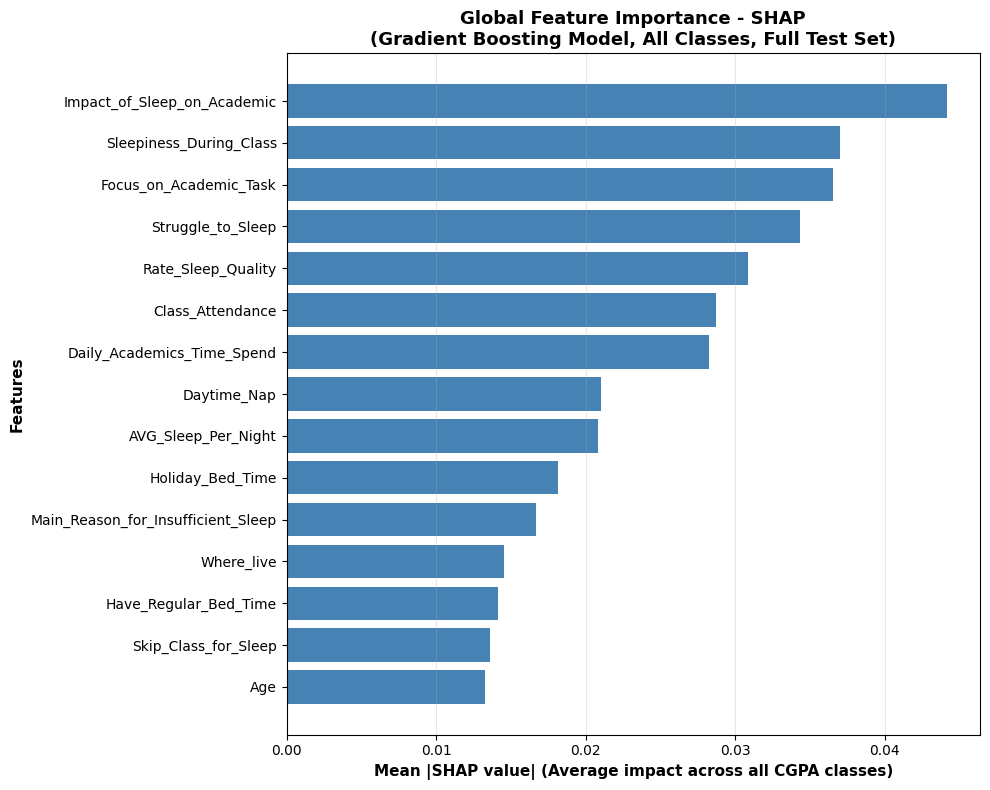


✅ STEP 3 COMPLETE!
   Based on 297 test samples across 3 CGPA classes.


In [61]:
# ============================================================================
# STEP 3: GLOBAL FEATURE IMPORTANCE - ALL 3 CLASSES AVERAGED
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n📊 Calculating Global Feature Importance (All 3 Classes Averaged)...")

# Average SHAP values across ALL samples AND ALL classes
shap_importance_all = np.abs(shap_values.values).mean(axis=(0, 2))

print(f"✓ SHAP values averaged across all 3 CGPA classes")
print(f"✓ Total samples used: {X_test.shape[0]}")
print(f"✓ Total features:     {len(feature_cols)}")

feature_importance_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': shap_importance_all
}).sort_values('Importance', ascending=False)

print("\n" + "="*80)
print("TOP 10 MOST IMPORTANT FEATURES (SHAP - ALL CLASSES - GRADIENT BOOSTING)")
print("="*80)
print(feature_importance_df.head(10).to_string(index=False))
print("="*80)

# Plot (inline only -- not saved)
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Mean |SHAP value| (Average impact across all CGPA classes)',
           fontsize=11, fontweight='bold')
plt.ylabel('Features', fontsize=11, fontweight='bold')
plt.title('Global Feature Importance - SHAP\n(Gradient Boosting Model, All Classes, Full Test Set)',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ STEP 3 COMPLETE!")
print(f"   Based on {X_test.shape[0]} test samples across 3 CGPA classes.")


📊 Generating SHAP Beeswarm Plot...


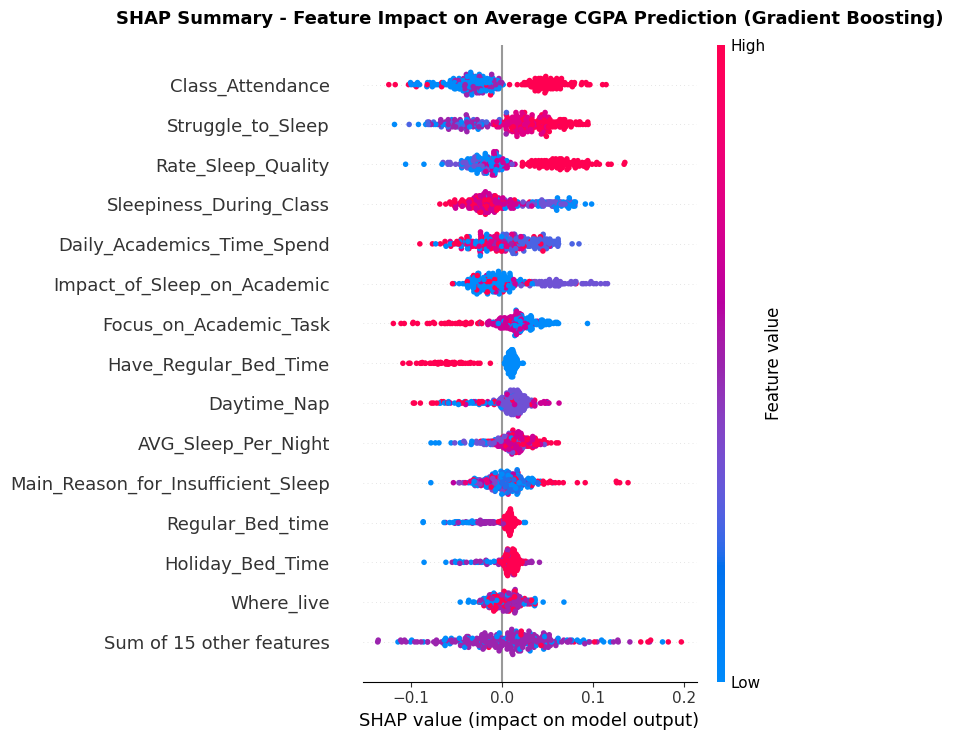


HOW TO READ THE BEESWARM PLOT:
• X-axis: SHAP value (impact on prediction)
  - Right (positive): Increases probability of Average CGPA
  - Left (negative): Decreases probability of Average CGPA
• Color: Feature value
  - Red/Pink: High feature value
  - Blue: Low feature value
• Y-axis: Features ranked by importance (top = most important)

✅ STEP 4 COMPLETE!


In [62]:
# ============================================================================
# STEP 4: BEESWARM PLOT (FEATURE IMPACT DIRECTION)
# ============================================================================

print("\n📊 Generating SHAP Beeswarm Plot...")

# Create the plot
plt.figure(figsize=(10, 8))

# Use the Explanation object directly for beeswarm
# Extract class 1 explanation
shap_explanation_class1 = shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[:, 1],
    data=X_test_sample.values if hasattr(X_test_sample, 'values') else X_test_sample,
    feature_names=feature_cols
)

shap.plots.beeswarm(shap_explanation_class1, max_display=15, show=False)
plt.title('SHAP Summary - Feature Impact on Average CGPA Prediction (Gradient Boosting)', 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("HOW TO READ THE BEESWARM PLOT:")
print("="*80)
print("• X-axis: SHAP value (impact on prediction)")
print("  - Right (positive): Increases probability of Average CGPA")
print("  - Left (negative): Decreases probability of Average CGPA")
print("• Color: Feature value")
print("  - Red/Pink: High feature value")
print("  - Blue: Low feature value")
print("• Y-axis: Features ranked by importance (top = most important)")
print("="*80)

print("\n✅ STEP 4 COMPLETE!")

In [70]:
# ============================================================================
# CHECK FEATURE ENCODING & RAW RELATIONSHIP WITH TARGET
# ============================================================================

import pandas as pd

# 1. Check unique values and their meaning (if you have a label encoder or mapping dict)
features_to_check = ['Struggle_to_Sleep', 'Class_Attendance', 'Rate_Sleep_Quality', 
                      'Daytime_Nap', 'Main_Reason_for_Insufficient_Sleep']

for feat in features_to_check:
    print(f"\n{'='*60}")
    print(f"Feature: {feat}")
    print(f"{'='*60}")
    print("Unique values (encoded):", sorted(df[feat].dropna().unique()))
    
    # If you kept the original raw/string column before encoding, print its mapping
    raw_col = feat + '_raw'  # adjust this if your raw column has a different name
    if raw_col in df.columns:
        mapping = df[[feat, raw_col]].drop_duplicates().sort_values(feat)
        print("\nEncoded -> Original mapping:")
        print(mapping.to_string(index=False))

# 2. Cross-tab: feature value vs target class (counts + proportions)
target_col = 'CGPA3_Class'

for feat in features_to_check:
    print(f"\n{'='*60}")
    print(f"{feat} vs {target_col} (row-normalized %)")
    print(f"{'='*60}")
    ct = pd.crosstab(df[feat], df[target_col], normalize='index') * 100
    print(ct.round(1))

# 3. Simple correlation with target (if target is ordinal/numeric-encoded)
print(f"\n{'='*60}")
print("Correlation with target (Spearman, handles ordinal data well)")
print(f"{'='*60}")
for feat in features_to_check:
    corr = df[feat].corr(df[target_col], method='spearman')
    print(f"{feat}: {corr:.3f}")

# 4. Group means of target by feature value (quick sanity check)
print("\nMean target value by feature level")
print("="*60)
for feat in features_to_check:
    print(f"\n{feat}:")
    print(df.groupby(feat)[target_col].mean().round(3))


Feature: Struggle_to_Sleep
Unique values (encoded): [np.float64(0.0), np.float64(0.01), np.float64(0.03), np.float64(0.04), np.float64(0.05), np.float64(0.06), np.float64(0.07), np.float64(0.08), np.float64(0.1), np.float64(0.11), np.float64(0.14), np.float64(0.15), np.float64(0.16), np.float64(0.17), np.float64(0.18), np.float64(0.19), np.float64(0.2), np.float64(0.21), np.float64(0.23), np.float64(0.24), np.float64(0.25), np.float64(0.26), np.float64(0.34), np.float64(0.35), np.float64(0.36), np.float64(0.37), np.float64(0.38), np.float64(0.39), np.float64(0.4), np.float64(0.41), np.float64(0.42), np.float64(0.43), np.float64(0.44), np.float64(0.45), np.float64(0.46), np.float64(0.47), np.float64(0.48), np.float64(0.49), np.float64(0.5), np.float64(0.51), np.float64(0.53), np.float64(0.54), np.float64(0.55), np.float64(0.56), np.float64(0.57), np.float64(0.58), np.float64(0.59), np.float64(0.6), np.float64(0.61), np.float64(0.62), np.float64(0.63), np.float64(0.64), np.float64(0.65)

In [65]:
print(df.columns.tolist())

['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Current_CGPA5', 'CGPA3_Class', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics', 'Target']


In [66]:
# Check if you saved a scaler object
print([v for v in dir() if 'scal' in v.lower() or 'encod' in v.lower()])

# If you have a saved scaler (e.g., scaler, mm_scaler, feature_scaler), inverse transform:
# Example (adjust variable names):
# original_values = scaler.inverse_transform(df[feature_cols])

# If no scaler object exists anymore, check your data prep code for how these were created

[]


In [67]:
print(df.columns.tolist())
print(df.dtypes)

['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Current_CGPA5', 'CGPA3_Class', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics', 'Target']
Age                                   float64
Gender                                float64
Where_live                            float64
AVG_Sleep_Per_Night                   float64
Regular_Bed_time                      float64
Exam_Night_Bed_Time                   float64
Holiday_Bed_Time 

In [68]:
# 1. Confirm relationship between Target and CGPA3_Class
print("Crosstab: Target vs CGPA3_Class")
print(pd.crosstab(df['Target'], df['CGPA3_Class']))

# 2. THE CRITICAL CHECK — did CGPA columns leak into training features?
print("\nfeature_cols currently used for training:")
print(feature_cols)

print("\nLeakage check:")
print("Current_CGPA5 in feature_cols:", 'Current_CGPA5' in feature_cols)
print("CGPA3_Class in feature_cols:", 'CGPA3_Class' in feature_cols)
print("Target in feature_cols:", 'Target' in feature_cols)

Crosstab: Target vs CGPA3_Class
CGPA3_Class    0    1    2
Target                    
0            524    0    0
1              0  486    0
2              0    0  524

feature_cols currently used for training:
['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']

Leakage check:
Current_CGPA5 in feature_cols: False
CGPA3_Class in feature_cols: False
Target in feature_cols: False


In [69]:
features_to_check = ['Struggle_to_Sleep', 'Class_Attendance', 'Rate_Sleep_Quality', 
                      'Daytime_Nap', 'Main_Reason_for_Insufficient_Sleep']

# Quartile-binned crosstab vs target
for feat in features_to_check:
    print(f"\n{'='*60}")
    print(f"{feat} (quartile-binned) vs Target")
    print(f"{'='*60}")
    binned = pd.qcut(df[feat], q=4, duplicates='drop')
    ct = pd.crosstab(binned, df['Target'], normalize='index') * 100
    print(ct.round(1))

# Spearman correlation with target
print(f"\n{'='*60}")
print("Spearman correlation with Target")
print(f"{'='*60}")
for feat in features_to_check:
    corr = df[feat].corr(df['Target'], method='spearman')
    print(f"{feat}: {corr:.3f}")

# Mean feature value by target class
print(f"\n{'='*60}")
print("Mean (scaled) feature value by Target class")
print(f"{'='*60}")
for feat in features_to_check:
    print(f"\n{feat}:")
    print(df.groupby('Target')[feat].mean().round(3))


Struggle_to_Sleep (quartile-binned) vs Target
Target                0     1     2
Struggle_to_Sleep                  
(-0.001, 0.432]    18.2  14.6  67.2
(0.432, 0.75]      40.4  35.9  23.7
(0.75, 1.0]        38.1  39.6  22.3

Class_Attendance (quartile-binned) vs Target
Target               0     1     2
Class_Attendance                  
(-0.001, 0.333]   32.8  27.8  39.4
(0.333, 0.667]    37.4  40.4  22.2
(0.667, 1.0]      26.8  15.5  57.7

Rate_Sleep_Quality (quartile-binned) vs Target
Target                 0     1     2
Rate_Sleep_Quality                  
(-0.001, 0.5]       36.0  31.5  32.5
(0.5, 0.75]         27.4  24.7  47.9
(0.75, 1.0]         35.5  34.9  29.6

Daytime_Nap (quartile-binned) vs Target
Target              0     1      2
Daytime_Nap                       
(-0.001, 0.333]  36.2  33.9   29.9
(0.333, 0.34]     0.0   0.0  100.0
(0.34, 1.0]      28.4  25.3   46.4

Main_Reason_for_Insufficient_Sleep (quartile-binned) vs Target
Target                                 

## 16. Summary

- Corrected the primary 80/20 workflow: 1,481 original real observations were split stratified before preprocessing and CTGAN into 1,184 real training observations and 297 untouched real test observations.
- Training-only normalization parameters were applied to both training and test predictors; target class labels remained unnormalized.
- CTGAN was trained only on the 174 real minority training observations, generated 350 synthetic minority training observations, and produced 1,534 augmented training observations.
- All six models were trained on the augmented training data and the primary metrics were calculated only on the 297 untouched real test observations.
- The inherited 5-fold CV analysis remains separate and is not leakage-corrected. It is not the corrected primary evaluation or a final leakage-safe validation estimate; a separate leakage-safe 5-fold CV analysis will be performed later.
- Feature importance, SHAP, and historical analysis sections are retained separately from the corrected primary 80/20 results.
